In [ ]:
# COMP541 organized folder path helper
from pathlib import Path
import os

def _comp541_phase_dir():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == 'code':
        return cwd.parent
    if (cwd / 'Input').exists() and (cwd / 'Output').exists():
        return cwd
    if (cwd.parent / 'Input').exists() and (cwd.parent / 'Output').exists():
        return cwd.parent
    # Fallback for the intended layout: notebook/script is inside a Code folder.
    return cwd.parent if cwd.name.lower() == 'code' else cwd

PHASE_DIR = _comp541_phase_dir()
INPUT_DIR = PHASE_DIR / 'Input'
OUTPUT_DIR = PHASE_DIR / 'Output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('INPUT_DIR :', INPUT_DIR.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())


In [49]:
import os

print(os.listdir())

['.config', 'kaggle_cost_of_living_prepared.csv', 'worldbank_tourism_prepared.csv', 'drive', 'sample_data']


# Assignment 1

In [51]:
import os
import pandas as pd

# Find CSV files from OneDrive automatically
onedrive_root = str(INPUT_DIR)

files_in_onedrive = []

for root, dirs, files in os.walk(onedrive_root):
    for file in files:
        if file.endswith(".csv"):
            files_in_onedrive.append(os.path.join(root, file))

ARRIVALS_FILE = [
    f for f in files_in_onedrive
    if "arrivals" in os.path.basename(f).lower()
][0]

RECEIPTS_FILE = [
    f for f in files_in_onedrive
    if "receipts" in os.path.basename(f).lower()
][0]

OUTPUT_FILE = OUTPUT_DIR / "worldbank_tourism_clean.csv"
QUALITY_FILE = OUTPUT_DIR / "worldbank_tourism_data_quality_summary.csv"

print("Using arrivals file:", ARRIVALS_FILE)
print("Using receipts file:", RECEIPTS_FILE)

# Load raw files
arrivals = pd.read_csv(ARRIVALS_FILE, skiprows=4)
receipts = pd.read_csv(RECEIPTS_FILE, skiprows=4)

print("Files loaded successfully.")
print("Arrivals raw shape:", arrivals.shape)
print("Receipts raw shape:", receipts.shape)

# Remove empty columns
arrivals = arrivals.dropna(axis=1, how="all")
receipts = receipts.dropna(axis=1, how="all")

# Identify year columns
year_cols_arrivals = [col for col in arrivals.columns if str(col).isdigit()]
year_cols_receipts = [col for col in receipts.columns if str(col).isdigit()]

print("Arrivals year columns found:", len(year_cols_arrivals))
print("Receipts year columns found:", len(year_cols_receipts))

# Reshape arrivals
arrivals_long = arrivals.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols_arrivals,
    var_name="Year",
    value_name="Tourism_Arrivals"
)

arrivals_long["Year"] = pd.to_numeric(arrivals_long["Year"], errors="coerce")
arrivals_long["Tourism_Arrivals"] = pd.to_numeric(arrivals_long["Tourism_Arrivals"], errors="coerce")

arrivals_long = arrivals_long[
    ["Country Name", "Country Code", "Year", "Tourism_Arrivals"]
].copy()

arrivals_long = arrivals_long.dropna(subset=["Tourism_Arrivals"])

# Reshape receipts
receipts_long = receipts.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols_receipts,
    var_name="Year",
    value_name="Tourism_Receipts_USD"
)

receipts_long["Year"] = pd.to_numeric(receipts_long["Year"], errors="coerce")
receipts_long["Tourism_Receipts_USD"] = pd.to_numeric(receipts_long["Tourism_Receipts_USD"], errors="coerce")

receipts_long = receipts_long[
    ["Country Name", "Country Code", "Year", "Tourism_Receipts_USD"]
].copy()

receipts_long = receipts_long.dropna(subset=["Tourism_Receipts_USD"])

# Keep most recent available year for arrivals
arrivals_recent = (
    arrivals_long
    .sort_values(["Country Name", "Year"])
    .groupby(["Country Name", "Country Code"], as_index=False)
    .tail(1)
    .rename(columns={
        "Country Name": "Country",
        "Country Code": "Country_Code",
        "Year": "Arrivals_Year"
    })
)

# Keep most recent available year for receipts
receipts_recent = (
    receipts_long
    .sort_values(["Country Name", "Year"])
    .groupby(["Country Name", "Country Code"], as_index=False)
    .tail(1)
    .rename(columns={
        "Country Name": "Country",
        "Country Code": "Country_Code",
        "Year": "Receipts_Year"
    })
)

# Merge arrivals and receipts
worldbank_clean = arrivals_recent.merge(
    receipts_recent,
    on=["Country", "Country_Code"],
    how="outer"
)

# Remove regional aggregate rows
non_country_codes = [
    "AFE", "AFW", "ARB", "CEB", "CSS", "EAP", "EAR", "EAS", "ECA",
    "ECS", "EMU", "EUU", "FCS", "HIC", "HPC", "IBD", "IBT", "IDA",
    "IDB", "IDX", "LAC", "LCN", "LDC", "LIC", "LMC", "LMY", "LTE",
    "MEA", "MIC", "MNA", "NAC", "OED", "OSS", "PRE", "PSS", "PST",
    "SAS", "SSA", "SSF", "SST", "TEA", "TEC", "TLA", "TMN", "TSA",
    "TSS", "UMC", "WLD"
]

worldbank_clean = worldbank_clean[
    ~worldbank_clean["Country_Code"].isin(non_country_codes)
].copy()

# Standardize country names
country_fixes = {
    "Turkiye": "Turkey",
    "Türkiye": "Turkey",
    "Czechia": "Czech Republic",
    "Korea, Rep.": "South Korea",
    "Egypt, Arab Rep.": "Egypt",
    "Russian Federation": "Russia"
}

worldbank_clean["Country"] = worldbank_clean["Country"].replace(country_fixes)

# Sort final data
worldbank_clean = worldbank_clean.sort_values("Country").reset_index(drop=True)

# Create data quality summary
data_quality_summary = pd.DataFrame({
    "Column": worldbank_clean.columns,
    "Missing_Values": worldbank_clean.isna().sum().values,
    "Data_Type": worldbank_clean.dtypes.astype(str).values
})

print("\nCleaned World Bank preview:")
display(worldbank_clean.head())

print("\nCleaned World Bank shape:")
print(worldbank_clean.shape)

print("\nMissing values:")
print(worldbank_clean.isna().sum())

print("\nData quality summary:")
display(data_quality_summary)

# Export cleaned files
worldbank_clean.to_csv(OUTPUT_FILE, index=False)
data_quality_summary.to_csv(QUALITY_FILE, index=False)

print("\nExport complete.")
print(f"Saved file: {OUTPUT_FILE}")
print(f"Saved file: {QUALITY_FILE}")

Using arrivals file: /content/drive/MyDrive/worldbank_tourism_arrivals_raw.csv
Using receipts file: /content/drive/MyDrive/worldbank_tourism_receipts_raw.csv
Files loaded successfully.
Arrivals raw shape: (266, 71)
Receipts raw shape: (266, 71)
Arrivals year columns found: 26
Receipts year columns found: 26

Cleaned World Bank preview:


,Country,Country_Code,Arrivals_Year,Tourism_Arrivals,Receipts_Year,Tourism_Receipts_USD
0,Afghanistan,AFG,NaN,NaN,"2,020.00","75,000,000.00"
1,Albania,ALB,"2,020.00","2,658,000.00","2,020.00","1,243,000,000.00"
2,Algeria,DZA,"2,020.00","591,000.00","2,020.00","50,000,000.00"
3,American Samoa,ASM,"2,020.00",900.00,"2,017.00","22,000,000.00"
4,Andorra,AND,"2,020.00","5,207,000.00","2,019.00","1,910,000,000.00"



Cleaned World Bank shape:
(208, 6)

Missing values:
Country                 0
Country_Code            0
Arrivals_Year           5
Tourism_Arrivals        5
Receipts_Year           5
Tourism_Receipts_USD    5
dtype: int64

Data quality summary:


,Column,Missing_Values,Data_Type
0,Country,0,object
1,Country_Code,0,object
2,Arrivals_Year,5,float64
3,Tourism_Arrivals,5,float64
4,Receipts_Year,5,float64
5,Tourism_Receipts_USD,5,float64



Export complete.
Saved file: /content/drive/MyDrive/worldbank_tourism_clean.csv
Saved file: /content/drive/MyDrive/worldbank_tourism_data_quality_summary.csv


In [52]:
import os
import pandas as pd

# ---------------------------------------------------------
# 1. Find Kaggle cost-of-living file from OneDrive automatically
# ---------------------------------------------------------

onedrive_root = str(INPUT_DIR)

files_in_onedrive = []

for root, dirs, files in os.walk(onedrive_root):
    for file in files:
        if file.endswith(".csv"):
            files_in_onedrive.append(os.path.join(root, file))

print("CSV files found:")
for f in files_in_onedrive:
    print(f)

COST_FILE = [
    f for f in files_in_onedrive
    if "cost-of-living_raw" in os.path.basename(f).lower()
][0]

OUTPUT_FILE = OUTPUT_DIR / "kaggle_cost_of_living_clean.csv"
QUALITY_FILE = OUTPUT_DIR / "kaggle_cost_of_living_data_quality_summary.csv"

print("\nUsing cost-of-living file:", COST_FILE)

# ---------------------------------------------------------
# 2. Load raw Kaggle cost-of-living data
# ---------------------------------------------------------

cost = pd.read_csv(COST_FILE)

print("Raw shape:", cost.shape)
print("Raw columns:")
print(cost.columns)

# ---------------------------------------------------------
# 3. Standardize column names
# ---------------------------------------------------------

cost.columns = (
    cost.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.lower()
)

# ---------------------------------------------------------
# 4. Remove completely empty rows and columns
# ---------------------------------------------------------

cost = cost.dropna(axis=0, how="all")
cost = cost.dropna(axis=1, how="all")

# ---------------------------------------------------------
# 5. Remove duplicate rows
# ---------------------------------------------------------

cost = cost.drop_duplicates()

# ---------------------------------------------------------
# 6. Clean city and country text
# ---------------------------------------------------------

cost["city"] = cost["city"].astype(str).str.strip()
cost["country"] = cost["country"].astype(str).str.strip()

# Replace text "nan" with actual missing values
cost["city"] = cost["city"].replace("nan", pd.NA)
cost["country"] = cost["country"].replace("nan", pd.NA)

# Remove rows missing city or country
cost = cost.dropna(subset=["city", "country"])

# ---------------------------------------------------------
# 7. Convert numeric indicator columns
# ---------------------------------------------------------

numeric_cols = [col for col in cost.columns if col not in ["city", "country"]]

for col in numeric_cols:
    cost[col] = (
        cost[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    cost[col] = pd.to_numeric(cost[col], errors="coerce")

# ---------------------------------------------------------
# 8. Create destination key for future merging
# ---------------------------------------------------------

cost["destination_key"] = (
    cost["city"].str.lower().str.replace(" ", "_", regex=False)
    + "_"
    + cost["country"].str.lower().str.replace(" ", "_", regex=False)
)

# ---------------------------------------------------------
# 9. Reorder columns
# ---------------------------------------------------------

first_cols = ["city", "country", "destination_key"]
other_cols = [col for col in cost.columns if col not in first_cols]

cost_clean = cost[first_cols + other_cols].copy()

# ---------------------------------------------------------
# 10. Sort data
# ---------------------------------------------------------

cost_clean = cost_clean.sort_values(["country", "city"]).reset_index(drop=True)

# ---------------------------------------------------------
# 11. Create data quality summary
# ---------------------------------------------------------

data_quality_summary = pd.DataFrame({
    "Column": cost_clean.columns,
    "Missing_Values": cost_clean.isna().sum().values,
    "Data_Type": cost_clean.dtypes.astype(str).values
})

# ---------------------------------------------------------
# 12. Print report information
# ---------------------------------------------------------

print("\nCleaned cost-of-living preview:")
display(cost_clean.head())

print("\nCleaned cost-of-living shape:")
print(cost_clean.shape)

print("\nMissing values:")
print(cost_clean.isna().sum())

print("\nData quality summary:")
display(data_quality_summary)

# ---------------------------------------------------------
# 13. Export cleaned files
# ---------------------------------------------------------

cost_clean.to_csv(OUTPUT_FILE, index=False)
data_quality_summary.to_csv(QUALITY_FILE, index=False)

print("\nExport complete.")
print(f"Saved file: {OUTPUT_FILE}")
print(f"Saved file: {QUALITY_FILE}")

CSV files found:
/content/drive/MyDrive/worldbank_tourism_clean.csv
/content/drive/MyDrive/flight_data_clean.csv
/content/drive/MyDrive/inside_airbnb_global_destination_summary_with_usd.csv
/content/drive/MyDrive/kaggle_cost_of_living_prepared.csv
/content/drive/MyDrive/TripAdvisor cleaned.csv
/content/drive/MyDrive/weather_monthly.csv
/content/drive/MyDrive/integrated_destinations_union.csv
/content/drive/MyDrive/modeling_candidates_union.csv
/content/drive/MyDrive/kaggle_cost_of_living_clean.csv
/content/drive/MyDrive/worldbank_tourism_prepared.csv
/content/drive/MyDrive/cost-of-living_raw.csv
/content/drive/MyDrive/worldbank_tourism_receipts_raw.csv
/content/drive/MyDrive/worldbank_tourism_arrivals_raw.csv
/content/drive/MyDrive/worldbank_tourism_data_quality_summary.csv

Using cost-of-living file: /content/drive/MyDrive/cost-of-living_raw.csv
Raw shape: (4956, 58)
Raw columns:
Index(['city', 'country', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9',
       'x10', 'x11', 'x12'

,city,country,destination_key,x1,x2,x3,x4,x5,x6,x7,...,x47,x48,x49,x50,x51,x52,x53,x54,x55,data_quality
0,Gardez,Afghanistan,gardez_afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,Herat,Afghanistan,herat_afghanistan,1.69,6.21,2.82,2.26,NaN,0.56,0.40,...,19.77,62.15,39.55,112.99,79.10,480.78,248.42,152.54,10.30,0
2,Jalalabad,Afghanistan,jalalabad_afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,90.40,NaN,NaN,NaN,NaN,NaN,NaN,9.40,0
3,Kabul,Afghanistan,kabul_afghanistan,1.69,5.65,3.11,NaN,NaN,0.93,0.23,...,36.16,108.92,64.97,228.81,146.89,694.92,355.93,195.86,13.88,1
4,Mazar-e Sharif,Afghanistan,mazar-e_sharif_afghanistan,1.69,7.81,2.99,NaN,NaN,0.45,0.34,...,NaN,67.80,33.90,112.99,56.50,282.49,112.99,225.99,NaN,0



Cleaned cost-of-living shape:
(4956, 59)

Missing values:
city                  0
country               0
destination_key       0
x1                  428
x2                  451
x3                  334
x4                  496
x5                  440
x6                  344
x7                  445
x8                  316
x9                  378
x10                 413
x11                 343
x12                 507
x13                 478
x14                 558
x15                 566
x16                 372
x17                 381
x18                 441
x19                 469
x20                 437
x21                 433
x22                 501
x23                 388
x24                 462
x25                 721
x26                 655
x27                 490
x28                1506
x29                2166
x30                 873
x31                1022
x32                1396
x33                 588
x34                1058
x35                 995
x36                 488
x37  

,Column,Missing_Values,Data_Type
0,city,0,object
1,country,0,object
2,destination_key,0,object
3,x1,428,float64
4,x2,451,float64
5,x3,334,float64
6,x4,496,float64
7,x5,440,float64
8,x6,344,float64
9,x7,445,float64



Export complete.
Saved file: /content/drive/MyDrive/kaggle_cost_of_living_clean.csv
Saved file: /content/drive/MyDrive/kaggle_cost_of_living_data_quality_summary.csv


# Assignment 2

In [ ]:
# Google Drive import removed; using organized Input/Output folders
# drive.mount removed; using organized Input/Output folders


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Check for cleaned files in the organized Input folder
for filename in ['worldbank_tourism_clean.csv', 'kaggle_cost_of_living_clean.csv']:
    path = INPUT_DIR / filename
    print(filename, 'FOUND' if path.exists() else 'NOT FOUND', '-', path)


WorldBank: /content/drive/MyDrive/worldbank_tourism_clean.csv
Cost: /content/drive/MyDrive/kaggle_cost_of_living_clean.csv


In [ ]:
# ============================================================
# Load cleaned Assignment 1 files from Google Drive
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
# Google Drive import removed; using organized Input/Output folders

# Mount Google Drive
# drive.mount removed; using organized Input/Output folders

# File paths from your Google Drive
worldbank_path = INPUT_DIR / "worldbank_tourism_clean.csv"
cost_path = INPUT_DIR / "kaggle_cost_of_living_clean.csv"

# Load both datasets
worldbank = pd.read_csv(worldbank_path)
cost = pd.read_csv(cost_path)

# Quick confirmation
print("Files loaded successfully")
print("World Bank Tourism Data shape:", worldbank.shape)
print("Kaggle Cost of Living Data shape:", cost.shape)

print("\nWorld Bank columns:")
print(worldbank.columns.tolist())

print("\nCost of Living columns:")
print(cost.columns.tolist())

display(worldbank.head())
display(cost.head())
print(cost.columns.tolist())

Mounted at /content/drive
Files loaded successfully
World Bank Tourism Data shape: (208, 6)
Kaggle Cost of Living Data shape: (4956, 59)

World Bank columns:
['Country', 'Country_Code', 'Arrivals_Year', 'Tourism_Arrivals', 'Receipts_Year', 'Tourism_Receipts_USD']

Cost of Living columns:
['city', 'country', 'destination_key', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'x50', 'x51', 'x52', 'x53', 'x54', 'x55', 'data_quality']


,Country,Country_Code,Arrivals_Year,Tourism_Arrivals,Receipts_Year,Tourism_Receipts_USD
0,Afghanistan,AFG,NaN,NaN,"2,020.00","75,000,000.00"
1,Albania,ALB,"2,020.00","2,658,000.00","2,020.00","1,243,000,000.00"
2,Algeria,DZA,"2,020.00","591,000.00","2,020.00","50,000,000.00"
3,American Samoa,ASM,"2,020.00",900.00,"2,017.00","22,000,000.00"
4,Andorra,AND,"2,020.00","5,207,000.00","2,019.00","1,910,000,000.00"


,city,country,destination_key,x1,x2,x3,x4,x5,x6,x7,...,x47,x48,x49,x50,x51,x52,x53,x54,x55,data_quality
0,Gardez,Afghanistan,gardez_afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,Herat,Afghanistan,herat_afghanistan,1.69,6.21,2.82,2.26,NaN,0.56,0.40,...,19.77,62.15,39.55,112.99,79.10,480.78,248.42,152.54,10.30,0
2,Jalalabad,Afghanistan,jalalabad_afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,90.40,NaN,NaN,NaN,NaN,NaN,NaN,9.40,0
3,Kabul,Afghanistan,kabul_afghanistan,1.69,5.65,3.11,NaN,NaN,0.93,0.23,...,36.16,108.92,64.97,228.81,146.89,694.92,355.93,195.86,13.88,1
4,Mazar-e Sharif,Afghanistan,mazar-e_sharif_afghanistan,1.69,7.81,2.99,NaN,NaN,0.45,0.34,...,NaN,67.80,33.90,112.99,56.50,282.49,112.99,225.99,NaN,0


['city', 'country', 'destination_key', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'x50', 'x51', 'x52', 'x53', 'x54', 'x55', 'data_quality']


In [ ]:
print("World Bank Tourism Data Preview:")
display(worldbank.head())

print("Kaggle Cost of Living Data Preview:")
display(cost.head())

World Bank Tourism Data Preview:


,Country,Country_Code,Arrivals_Year,Tourism_Arrivals,Receipts_Year,Tourism_Receipts_USD
0,Afghanistan,AFG,NaN,NaN,"2,020.00","75,000,000.00"
1,Albania,ALB,"2,020.00","2,658,000.00","2,020.00","1,243,000,000.00"
2,Algeria,DZA,"2,020.00","591,000.00","2,020.00","50,000,000.00"
3,American Samoa,ASM,"2,020.00",900.00,"2,017.00","22,000,000.00"
4,Andorra,AND,"2,020.00","5,207,000.00","2,019.00","1,910,000,000.00"


Kaggle Cost of Living Data Preview:


,city,country,destination_key,x1,x2,x3,x4,x5,x6,x7,...,x47,x48,x49,x50,x51,x52,x53,x54,x55,data_quality
0,Gardez,Afghanistan,gardez_afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,Herat,Afghanistan,herat_afghanistan,1.69,6.21,2.82,2.26,NaN,0.56,0.40,...,19.77,62.15,39.55,112.99,79.10,480.78,248.42,152.54,10.30,0
2,Jalalabad,Afghanistan,jalalabad_afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,90.40,NaN,NaN,NaN,NaN,NaN,NaN,9.40,0
3,Kabul,Afghanistan,kabul_afghanistan,1.69,5.65,3.11,NaN,NaN,0.93,0.23,...,36.16,108.92,64.97,228.81,146.89,694.92,355.93,195.86,13.88,1
4,Mazar-e Sharif,Afghanistan,mazar-e_sharif_afghanistan,1.69,7.81,2.99,NaN,NaN,0.45,0.34,...,NaN,67.80,33.90,112.99,56.50,282.49,112.99,225.99,NaN,0


In [ ]:
print("World Bank Data Types:")
display(worldbank.dtypes)

print("World Bank Missing Values:")
display(worldbank.isna().sum())

print("Cost of Living Data Types:")
display(cost.dtypes)

print("Cost of Living Missing Values:")
display(cost.isna().sum())

World Bank Data Types:


,0
Country,object
Country_Code,object
Arrivals_Year,float64
Tourism_Arrivals,float64
Receipts_Year,float64
Tourism_Receipts_USD,float64


World Bank Missing Values:


,0
Country,0
Country_Code,0
Arrivals_Year,5
Tourism_Arrivals,5
Receipts_Year,5
Tourism_Receipts_USD,5


Cost of Living Data Types:


,0
city,object
country,object
destination_key,object
x1,float64
x2,float64
x3,float64
x4,float64
x5,float64
x6,float64
x7,float64


Cost of Living Missing Values:


,0
city,0
country,0
destination_key,0
x1,428
x2,451
x3,334
x4,496
x5,440
x6,344
x7,445


In [ ]:
# ------------------------------------------------------------
# 4. Rename selected cost-of-living columns for readability
# ------------------------------------------------------------

cost_named = cost.rename(columns={
    "x1": "Meal_Inexpensive_Restaurant",
    "x2": "Meal_For_2_Midrange",
    "x3": "McMeal_Combo",
    "x4": "Domestic_Beer_Draught",
    "x5": "Imported_Beer_Bottle",
    "x6": "Cappuccino",
    "x7": "Coke_Pepsi_0_33L",
    "x8": "Water_0_33L",
    "x9": "Milk_1L",
    "x10": "White_Bread_500g",
    "x11": "Rice_1kg",
    "x12": "Eggs_12",
    "x13": "Local_Cheese_1kg",
    "x14": "Chicken_Fillets_1kg",
    "x15": "Beef_1kg",
    "x16": "Apples_1kg",
    "x17": "Banana_1kg",
    "x18": "Oranges_1kg",
    "x19": "Tomato_1kg",
    "x20": "Potato_1kg",
    "x21": "Onion_1kg",
    "x22": "Lettuce",
    "x23": "Water_1_5L",
    "x24": "Wine_Midrange",
    "x25": "Domestic_Beer_Bottle",
    "x26": "Imported_Beer_Bottle_Market",
    "x27": "Cigarettes_20",
    "x28": "One_Way_Transport_Ticket",
    "x29": "Monthly_Transport_Pass",
    "x30": "Taxi_Start",
    "x31": "Taxi_1km",
    "x32": "Taxi_1hr_Waiting",
    "x33": "Gasoline_1L",
    "x34": "Volkswagen_Golf_New_Car",
    "x35": "Toyota_Corolla_New_Car",
    "x36": "Basic_Utilities",
    "x37": "Mobile_Tariff_1min",
    "x38": "Internet_Monthly",
    "x39": "Fitness_Club_Monthly",
    "x40": "Tennis_Court_Rent",
    "x41": "Cinema_Ticket",
    "x42": "Preschool_Monthly",
    "x43": "International_Primary_School_Yearly",
    "x44": "Jeans",
    "x45": "Summer_Dress",
    "x46": "Nike_Running_Shoes",
    "x47": "Men_Leather_Shoes",
    "x48": "Apartment_1BR_City_Centre_Rent",
    "x49": "Apartment_1BR_Outside_Centre_Rent",
    "x50": "Apartment_3BR_City_Centre_Rent",
    "x51": "Apartment_3BR_Outside_Centre_Rent",
    "x52": "Price_Per_Sqm_City_Centre",
    "x53": "Price_Per_Sqm_Outside_Centre",
    "x54": "Average_Monthly_Net_Salary",
    "x55": "Mortgage_Interest_Rate",
    "data_quality": "Data_Quality"
})

print("Renamed selected cost-of-living columns successfully.")
display(cost_named.head())

Renamed selected cost-of-living columns successfully.


,city,country,destination_key,Meal_Inexpensive_Restaurant,Meal_For_2_Midrange,McMeal_Combo,Domestic_Beer_Draught,Imported_Beer_Bottle,Cappuccino,Coke_Pepsi_0_33L,...,Men_Leather_Shoes,Apartment_1BR_City_Centre_Rent,Apartment_1BR_Outside_Centre_Rent,Apartment_3BR_City_Centre_Rent,Apartment_3BR_Outside_Centre_Rent,Price_Per_Sqm_City_Centre,Price_Per_Sqm_Outside_Centre,Average_Monthly_Net_Salary,Mortgage_Interest_Rate,Data_Quality
0,Gardez,Afghanistan,gardez_afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,Herat,Afghanistan,herat_afghanistan,1.69,6.21,2.82,2.26,NaN,0.56,0.40,...,19.77,62.15,39.55,112.99,79.10,480.78,248.42,152.54,10.30,0
2,Jalalabad,Afghanistan,jalalabad_afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,90.40,NaN,NaN,NaN,NaN,NaN,NaN,9.40,0
3,Kabul,Afghanistan,kabul_afghanistan,1.69,5.65,3.11,NaN,NaN,0.93,0.23,...,36.16,108.92,64.97,228.81,146.89,694.92,355.93,195.86,13.88,1
4,Mazar-e Sharif,Afghanistan,mazar-e_sharif_afghanistan,1.69,7.81,2.99,NaN,NaN,0.45,0.34,...,NaN,67.80,33.90,112.99,56.50,282.49,112.99,225.99,NaN,0


In [ ]:
# ------------------------------------------------------------
# 5. Create descriptive statistics tables
# ------------------------------------------------------------

def create_descriptive_stats(df_numeric):
    stats = df_numeric.describe().T
    stats["median"] = df_numeric.median()
    stats["mode"] = df_numeric.mode().iloc[0]
    stats["midrange"] = (df_numeric.min() + df_numeric.max()) / 2
    stats["range"] = df_numeric.max() - df_numeric.min()
    stats["variance"] = df_numeric.var()
    stats["skewness"] = df_numeric.skew()
    stats["missing_values"] = df_numeric.isna().sum()
    return stats

# World Bank numeric columns
worldbank_numeric = worldbank.select_dtypes(include=["number"])

# Cost of Living numeric columns using renamed version
cost_named_numeric = cost_named.select_dtypes(include=["number"])

# Create full descriptive statistics tables
worldbank_descriptive_stats = create_descriptive_stats(worldbank_numeric)
cost_descriptive_stats = create_descriptive_stats(cost_named_numeric)

print("World Bank Tourism Descriptive Statistics:")
display(worldbank_descriptive_stats)

print("Cost of Living Descriptive Statistics:")
display(cost_descriptive_stats)

World Bank Tourism Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max,median,mode,midrange,range,variance,skewness,missing_values
Arrivals_Year,203.00,"2,019.07",2.69,"1,998.00","2,019.00","2,020.00","2,020.00","2,020.00","2,020.00","2,020.00","2,009.00",22.00,7.21,-5.52,5
Tourism_Arrivals,203.00,"4,916,234.48","12,967,141.40",900.00,"289,000.00","903,000.00","3,293,000.00","117,109,000.00","903,000.00","217,000.00","58,554,950.00","117,108,100.00","168,146,756,041,426.19",5.43,5
Receipts_Year,203.00,"2,017.55",5.33,"1,995.00","2,018.00","2,020.00","2,020.00","2,020.00","2,020.00","2,020.00","2,007.50",25.00,28.43,-2.65,5
Tourism_Receipts_USD,203.00,"3,839,354,599.10","9,436,219,861.47","1,289,999.96","125,500,000.00","589,000,000.00","2,435,000,000.00","84,205,000,000.00","589,000,000.00","19,000,000.00","42,103,144,999.98","84,203,710,000.04","89,042,245,273,973,211,136.00",4.95,5


Cost of Living Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max,median,mode,midrange,range,variance,skewness,missing_values
Meal_Inexpensive_Restaurant,"4,528.00",10.35,7.16,0.45,4.31,9.60,15.00,57.14,9.60,15.00,28.80,56.69,51.22,1.10,428
Meal_For_2_Midrange,"4,505.00",43.36,25.53,3.25,22.44,40.00,60.00,213.69,40.00,52.69,108.47,210.44,651.69,0.81,451
McMeal_Combo,"4,622.00",6.93,2.70,1.08,4.98,6.99,8.50,22.13,6.99,8.00,11.61,21.05,7.31,0.72,334
Domestic_Beer_Draught,"4,460.00",3.38,2.11,0.33,1.60,3.00,5.00,20.60,3.00,5.00,10.46,20.27,4.44,0.99,496
Imported_Beer_Bottle,"4,516.00",3.94,2.10,0.31,2.20,3.69,5.27,17.50,3.69,6.00,8.90,17.19,4.41,0.95,440
Cappuccino,"4,612.00",2.75,1.36,0.22,1.58,2.63,3.77,10.00,2.63,4.00,5.11,9.78,1.85,0.44,344
Coke_Pepsi_0_33L,"4,511.00",1.52,0.91,0.11,0.77,1.48,2.11,8.00,1.48,2.00,4.05,7.89,0.82,0.82,445
Water_0_33L,"4,640.00",1.12,0.76,0.07,0.48,1.05,1.58,5.85,1.05,1.05,2.96,5.78,0.57,0.93,316
Milk_1L,"4,578.00",1.15,0.52,0.26,0.83,1.04,1.32,6.81,1.04,1.05,3.53,6.55,0.27,2.66,378
White_Bread_500g,"4,543.00",1.61,1.09,0.05,0.78,1.32,2.20,8.82,1.32,1.05,4.44,8.77,1.19,1.28,413


In [ ]:
# ------------------------------------------------------------
# 6. Central tendency tables
# ------------------------------------------------------------

# World Bank central tendency table
worldbank_central_tendency = worldbank_descriptive_stats[
    ["mean", "median", "mode", "midrange"]
].copy()

print("World Bank Central Tendency:")
display(worldbank_central_tendency)

# Selected cost-of-living indicators for readable report table
selected_cost_cols = [
    "McMeal_Combo",
    "Cappuccino",
    "Water_0_33L",
    "Rice_1kg",
    "Internet_Monthly",
    "Data_Quality"
]

cost_central_tendency = cost_descriptive_stats.loc[selected_cost_cols, [
    "mean", "median", "mode", "midrange"
]].copy()

print("Cost of Living Central Tendency:")
display(cost_central_tendency)

World Bank Central Tendency:


,mean,median,mode,midrange
Arrivals_Year,"2,019.07","2,020.00","2,020.00","2,009.00"
Tourism_Arrivals,"4,916,234.48","903,000.00","217,000.00","58,554,950.00"
Receipts_Year,"2,017.55","2,020.00","2,020.00","2,007.50"
Tourism_Receipts_USD,"3,839,354,599.10","589,000,000.00","19,000,000.00","42,103,144,999.98"


Cost of Living Central Tendency:


,mean,median,mode,midrange
McMeal_Combo,6.93,6.99,8.00,11.61
Cappuccino,2.75,2.63,4.00,5.11
Water_0_33L,1.12,1.05,1.05,2.96
Rice_1kg,2.19,1.69,2.11,7.84
Internet_Monthly,146.32,34.44,31.61,"242,996.57"
Data_Quality,0.19,0.00,0.00,0.50


In [ ]:
# ----------------------------
# Data Dispersion Tables
# ----------------------------

# World Bank dispersion table
worldbank_dispersion = worldbank_descriptive_stats[
    ["std", "min", "25%", "50%", "75%", "max", "range", "variance"]
].copy()

print("World Bank Tourism Data Dispersion:")
display(worldbank_dispersion)

# Cost of Living selected indicators
selected_cost_cols = [
    "McMeal_Combo",
    "Cappuccino",
    "Water_0_33L",
    "Rice_1kg",
    "Internet_Monthly",
    "Data_Quality"
]

cost_dispersion = cost_descriptive_stats.loc[selected_cost_cols, [
    "std", "min", "25%", "50%", "75%", "max", "range", "variance"
]].copy()

print("Cost of Living Data Dispersion:")
display(cost_dispersion)

World Bank Tourism Data Dispersion:


,std,min,25%,50%,75%,max,range,variance
Arrivals_Year,2.69,"1,998.00","2,019.00","2,020.00","2,020.00","2,020.00",22.00,7.21
Tourism_Arrivals,"12,967,141.40",900.00,"289,000.00","903,000.00","3,293,000.00","117,109,000.00","117,108,100.00","168,146,756,041,426.19"
Receipts_Year,5.33,"1,995.00","2,018.00","2,020.00","2,020.00","2,020.00",25.00,28.43
Tourism_Receipts_USD,"9,436,219,861.47","1,289,999.96","125,500,000.00","589,000,000.00","2,435,000,000.00","84,205,000,000.00","84,203,710,000.04","89,042,245,273,973,211,136.00"


Cost of Living Data Dispersion:


,std,min,25%,50%,75%,max,range,variance
McMeal_Combo,2.70,1.08,4.98,6.99,8.50,22.13,21.05,7.31
Cappuccino,1.36,0.22,1.58,2.63,3.77,10.00,9.78,1.85
Water_0_33L,0.76,0.07,0.48,1.05,1.58,5.85,5.78,0.57
Rice_1kg,1.63,0.25,1.05,1.69,2.74,15.43,15.18,2.67
Internet_Monthly,"7,159.59",1.36,18.83,34.44,57.95,"485,991.77","485,990.41","51,259,767.05"
Data_Quality,0.39,0.00,0.00,0.00,0.00,1.00,1.00,0.15


In [ ]:
# ----------------------------
# Skewness Tables for Report
# ----------------------------

# Tourism skewness table
worldbank_skewness = worldbank_descriptive_stats[["skewness"]].copy()

print("World Bank Tourism Skewness:")
display(worldbank_skewness)

# Cost of Living selected indicators
selected_cost_cols = [
    "McMeal_Combo",
    "Cappuccino",
    "Water_0_33L",
    "Rice_1kg",
    "Internet_Monthly",
    "Data_Quality"
]

cost_skewness = cost_descriptive_stats.loc[selected_cost_cols, ["skewness"]].copy()

print("Cost of Living Skewness:")
display(cost_skewness)

World Bank Tourism Skewness:


,skewness
Arrivals_Year,-5.52
Tourism_Arrivals,5.43
Receipts_Year,-2.65
Tourism_Receipts_USD,4.95


Cost of Living Skewness:


,skewness
McMeal_Combo,0.72
Cappuccino,0.44
Water_0_33L,0.93
Rice_1kg,2.13
Internet_Monthly,67.87
Data_Quality,1.61


In [ ]:
# ----------------------------
# Correlation Analysis
# ----------------------------

# World Bank correlation matrix
worldbank_corr = worldbank_numeric.corr()

print("World Bank Tourism Correlation Matrix:")
display(worldbank_corr)

# Cost of Living selected indicators
selected_cost_cols = [
    "McMeal_Combo",
    "Cappuccino",
    "Water_0_33L",
    "Rice_1kg",
    "Internet_Monthly",
    "Data_Quality"
]

cost_corr = cost_named[selected_cost_cols].corr()

print("Cost of Living Correlation Matrix:")
display(cost_corr)

World Bank Tourism Correlation Matrix:


,Arrivals_Year,Tourism_Arrivals,Receipts_Year,Tourism_Receipts_USD
Arrivals_Year,1.00,0.07,0.18,0.12
Tourism_Arrivals,0.07,1.00,0.01,0.54
Receipts_Year,0.18,0.01,1.00,-0.06
Tourism_Receipts_USD,0.12,0.54,-0.06,1.00


Cost of Living Correlation Matrix:


,McMeal_Combo,Cappuccino,Water_0_33L,Rice_1kg,Internet_Monthly,Data_Quality
McMeal_Combo,1.00,0.59,0.72,0.43,0.05,0.08
Cappuccino,0.59,1.00,0.62,0.62,0.02,0.05
Water_0_33L,0.72,0.62,1.00,0.46,0.00,0.06
Rice_1kg,0.43,0.62,0.46,1.00,-0.01,-0.02
Internet_Monthly,0.05,0.02,0.00,-0.01,1.00,-0.01
Data_Quality,0.08,0.05,0.06,-0.02,-0.01,1.00


World Bank Tourism Correlation Matrix:


,Arrivals_Year,Tourism_Arrivals,Receipts_Year,Tourism_Receipts_USD
Arrivals_Year,1.00,0.07,0.18,0.12
Tourism_Arrivals,0.07,1.00,0.01,0.54
Receipts_Year,0.18,0.01,1.00,-0.06
Tourism_Receipts_USD,0.12,0.54,-0.06,1.00


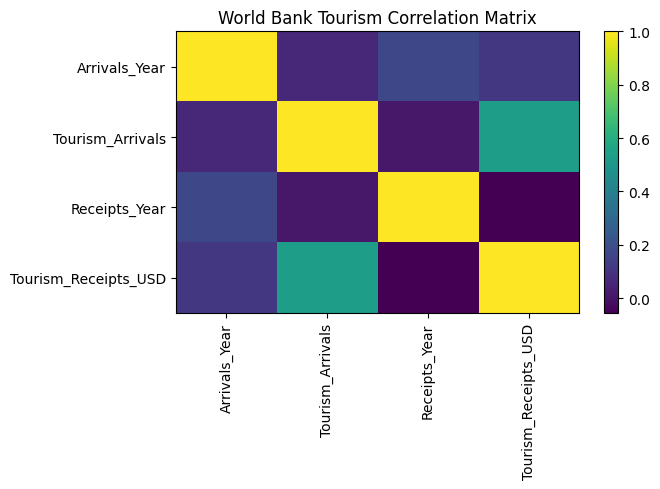

Cost of Living Correlation Matrix:


,McMeal_Combo,Cappuccino,Water_0_33L,Rice_1kg,Internet_Monthly,Data_Quality
McMeal_Combo,1.00,0.59,0.72,0.43,0.05,0.08
Cappuccino,0.59,1.00,0.62,0.62,0.02,0.05
Water_0_33L,0.72,0.62,1.00,0.46,0.00,0.06
Rice_1kg,0.43,0.62,0.46,1.00,-0.01,-0.02
Internet_Monthly,0.05,0.02,0.00,-0.01,1.00,-0.01
Data_Quality,0.08,0.05,0.06,-0.02,-0.01,1.00


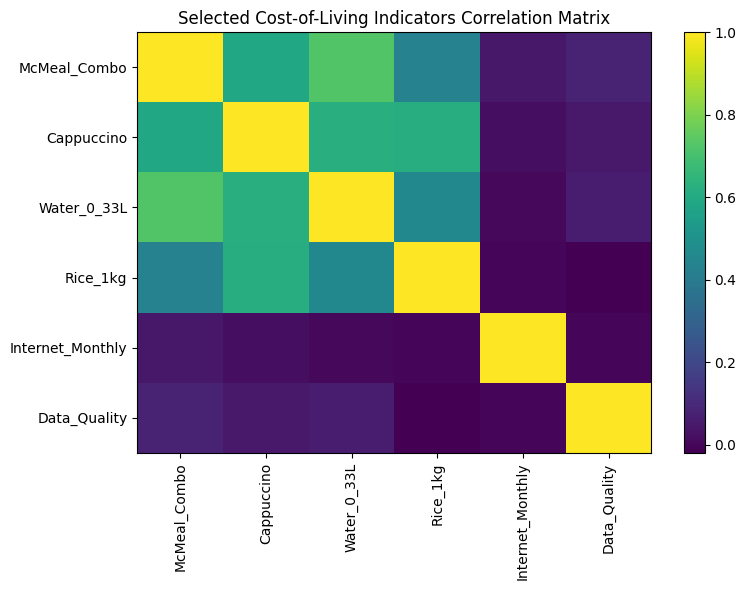

In [ ]:
# ----------------------------
# Correlation Analysis
# ----------------------------

# World Bank Tourism correlation
worldbank_corr = worldbank_numeric.corr()

print("World Bank Tourism Correlation Matrix:")
display(worldbank_corr)

plt.figure(figsize=(7, 5))
plt.imshow(worldbank_corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(worldbank_corr.columns)), worldbank_corr.columns, rotation=90)
plt.yticks(range(len(worldbank_corr.columns)), worldbank_corr.columns)
plt.title("World Bank Tourism Correlation Matrix")
plt.tight_layout()
plt.show()


# Cost of Living correlation
selected_cost_cols = [
    "McMeal_Combo",
    "Cappuccino",
    "Water_0_33L",
    "Rice_1kg",
    "Internet_Monthly",
    "Data_Quality"
]

cost_corr = cost_named[selected_cost_cols].corr()

print("Cost of Living Correlation Matrix:")
display(cost_corr)

plt.figure(figsize=(8, 6))
plt.imshow(cost_corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(cost_corr.columns)), cost_corr.columns, rotation=90)
plt.yticks(range(len(cost_corr.columns)), cost_corr.columns)
plt.title("Selected Cost-of-Living Indicators Correlation Matrix")
plt.tight_layout()
plt.show()

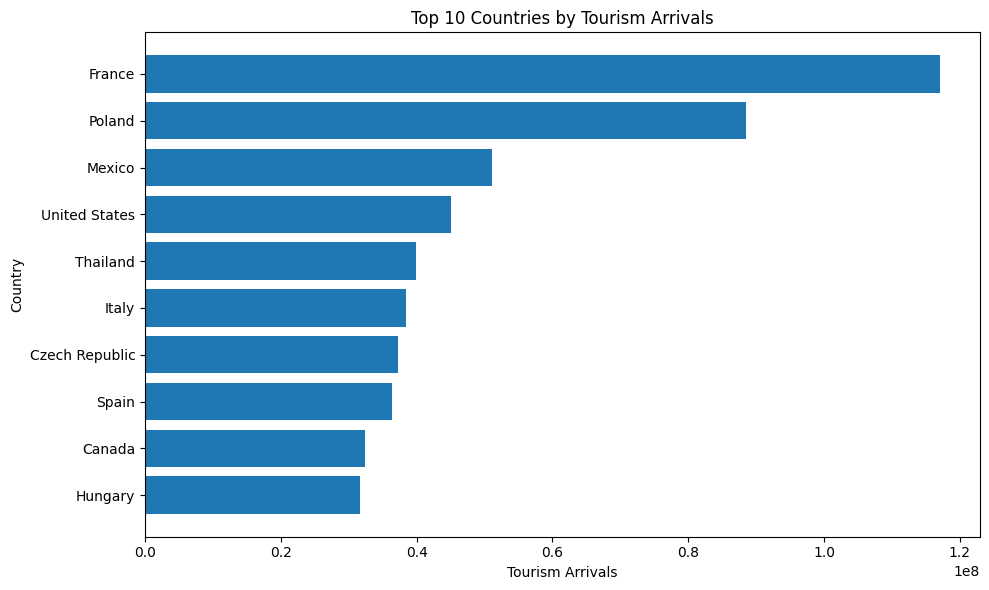

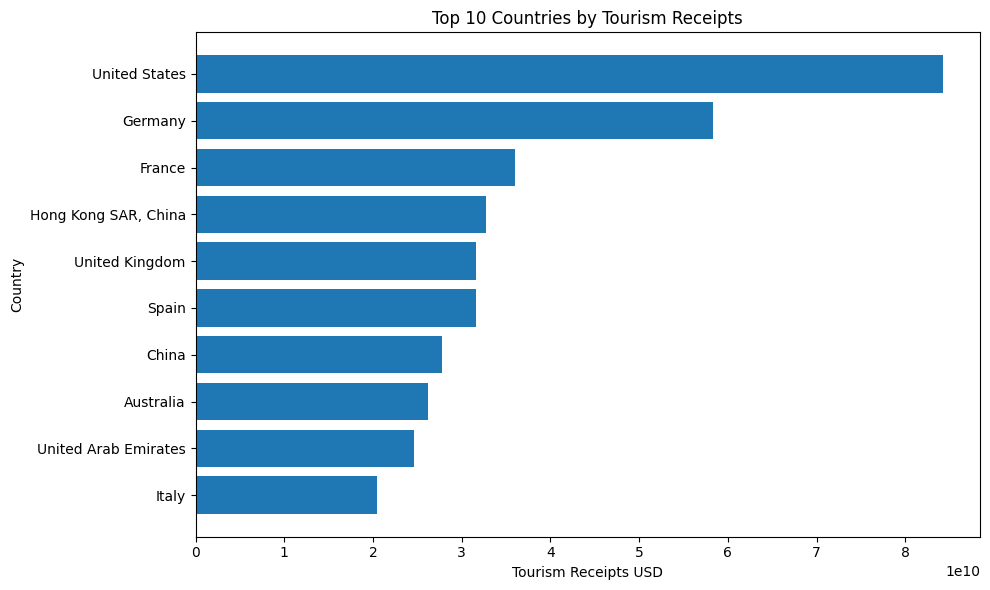

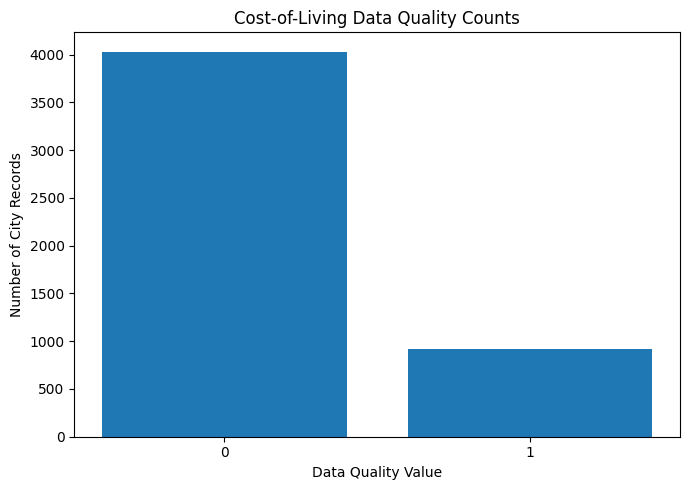

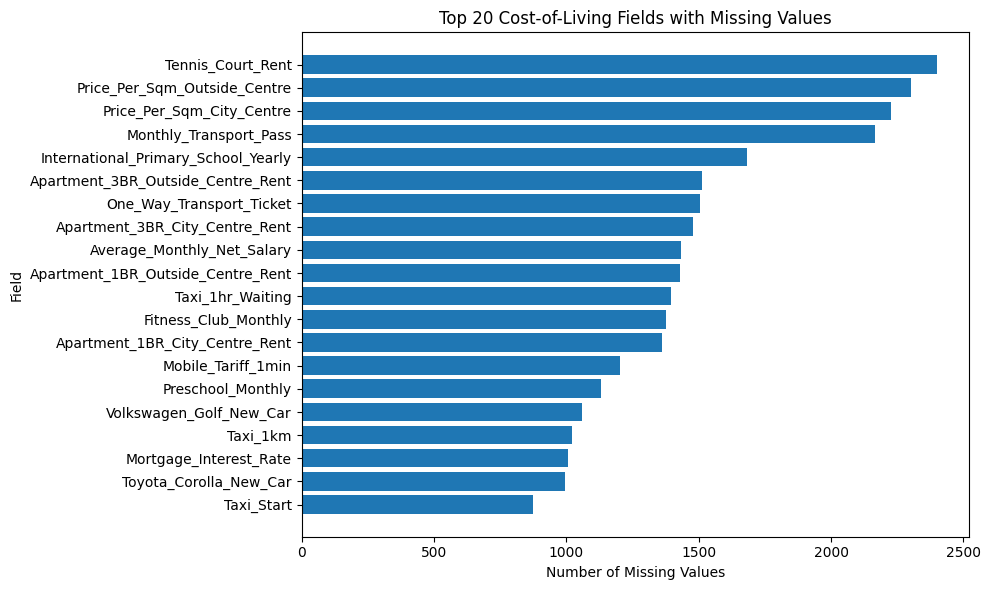

In [ ]:
# ----------------------------
# 6.2 Bar Plot
# ----------------------------

# Top 10 countries by tourism arrivals
top_arrivals = worldbank.sort_values("Tourism_Arrivals", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_arrivals["Country"], top_arrivals["Tourism_Arrivals"])
plt.title("Top 10 Countries by Tourism Arrivals")
plt.xlabel("Tourism Arrivals")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top 10 countries by tourism receipts
top_receipts = worldbank.sort_values("Tourism_Receipts_USD", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_receipts["Country"], top_receipts["Tourism_Receipts_USD"])
plt.title("Top 10 Countries by Tourism Receipts")
plt.xlabel("Tourism Receipts USD")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Cost of Living data quality counts
quality_counts = cost_named["Data_Quality"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(quality_counts.index.astype(str), quality_counts.values)
plt.title("Cost-of-Living Data Quality Counts")
plt.xlabel("Data Quality Value")
plt.ylabel("Number of City Records")
plt.tight_layout()
plt.show()

# Top 20 missing values in cost-of-living fields
cost_missing_top20 = cost_named.isna().sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(cost_missing_top20.index, cost_missing_top20.values)
plt.title("Top 20 Cost-of-Living Fields with Missing Values")
plt.xlabel("Number of Missing Values")
plt.ylabel("Field")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

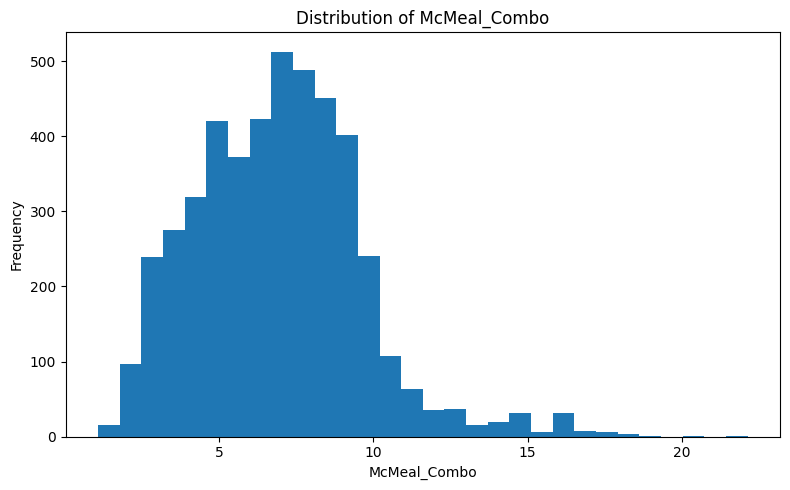

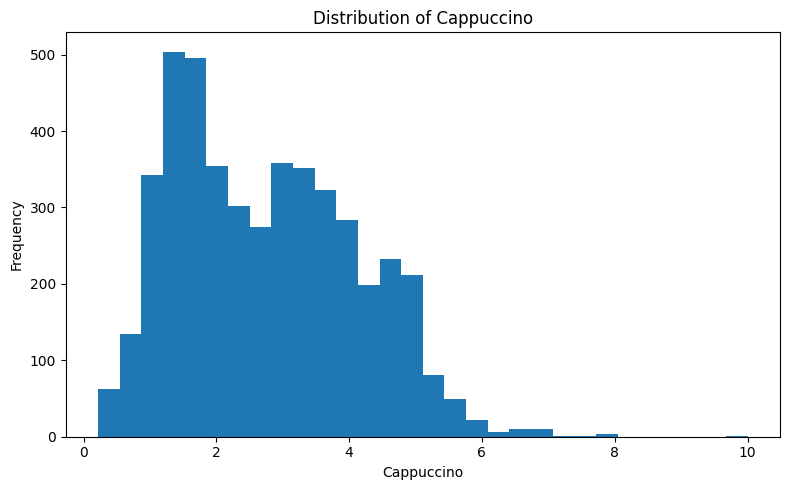

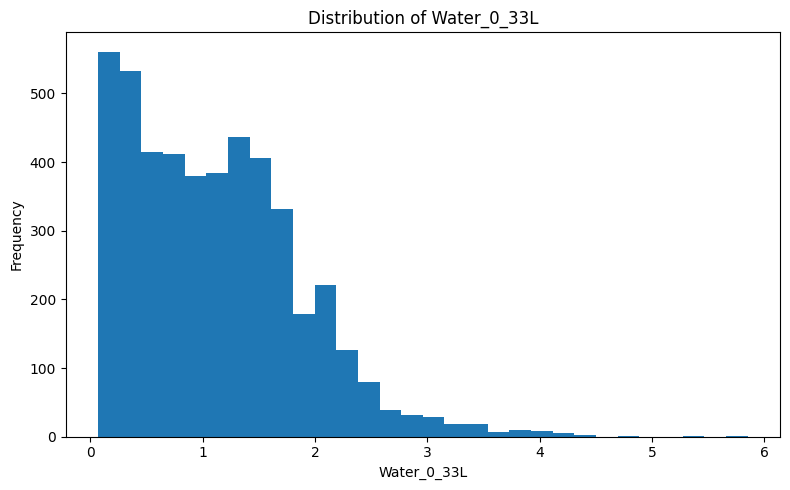

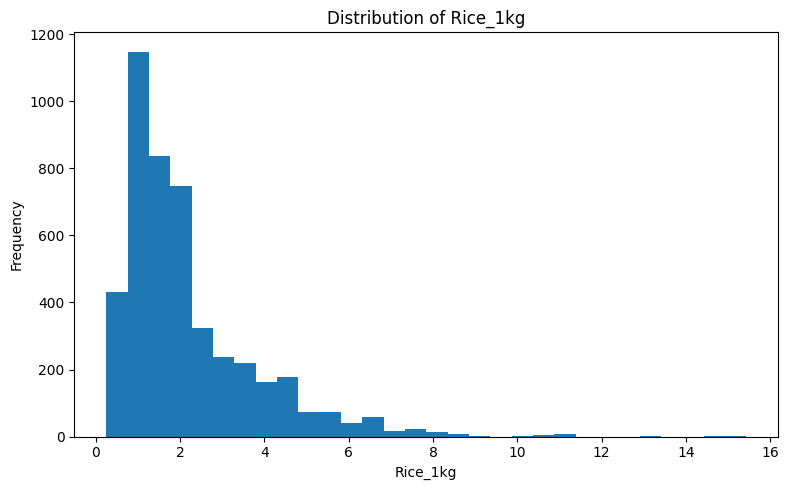

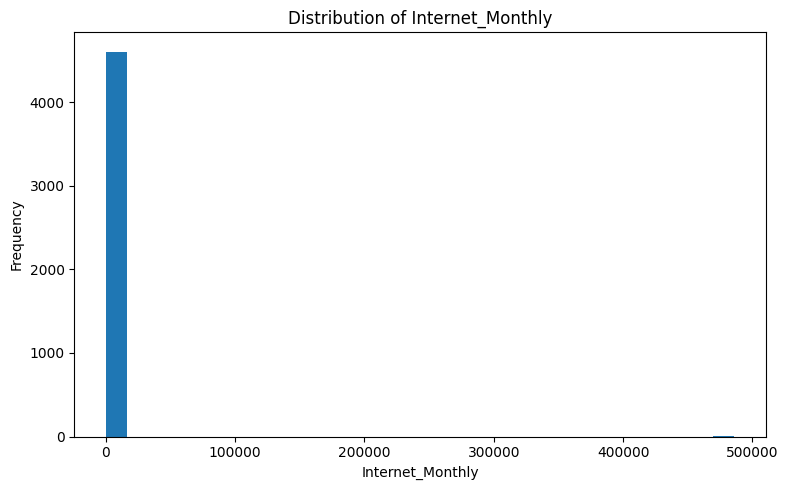

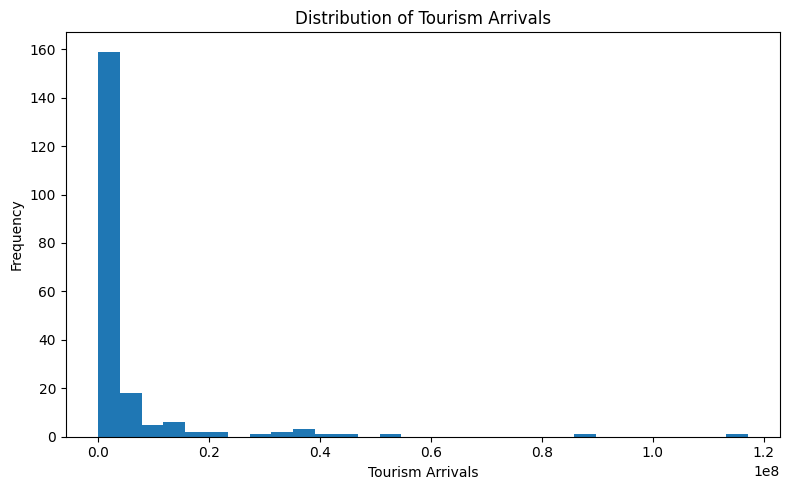

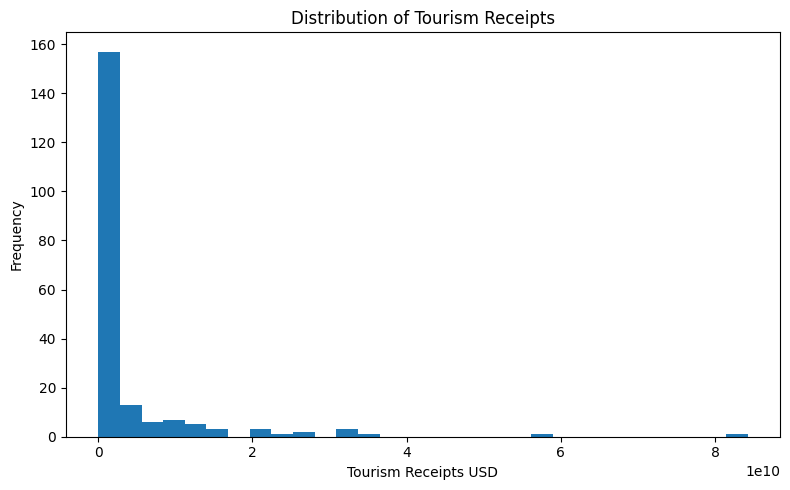

In [ ]:
# ----------------------------
# 6.3 Histogram
# Cost of Living first, then Tourism
# ----------------------------

# Cost of Living selected indicators
selected_cost_cols = [
    "McMeal_Combo",
    "Cappuccino",
    "Water_0_33L",
    "Rice_1kg",
    "Internet_Monthly"
]

# Cost of Living histograms
for col in selected_cost_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(cost_named[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


# Tourism histogram: Tourism Arrivals
plt.figure(figsize=(8, 5))
plt.hist(worldbank["Tourism_Arrivals"].dropna(), bins=30)
plt.title("Distribution of Tourism Arrivals")
plt.xlabel("Tourism Arrivals")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Tourism histogram: Tourism Receipts
plt.figure(figsize=(8, 5))
plt.hist(worldbank["Tourism_Receipts_USD"].dropna(), bins=30)
plt.title("Distribution of Tourism Receipts")
plt.xlabel("Tourism Receipts USD")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

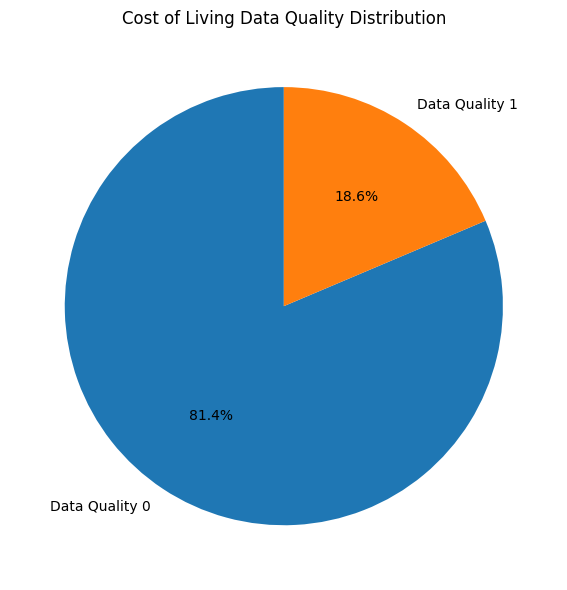

In [ ]:
# ----------------------------
# 6.4 Pie Plot
# Cost of Living first, then Tourism
# ----------------------------

# Cost of Living pie chart: Data Quality distribution
quality_counts = cost_named["Data_Quality"].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(
    quality_counts.values,
    labels=[f"Data Quality {label}" for label in quality_counts.index],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Cost of Living Data Quality Distribution")
plt.tight_layout()
plt.show()

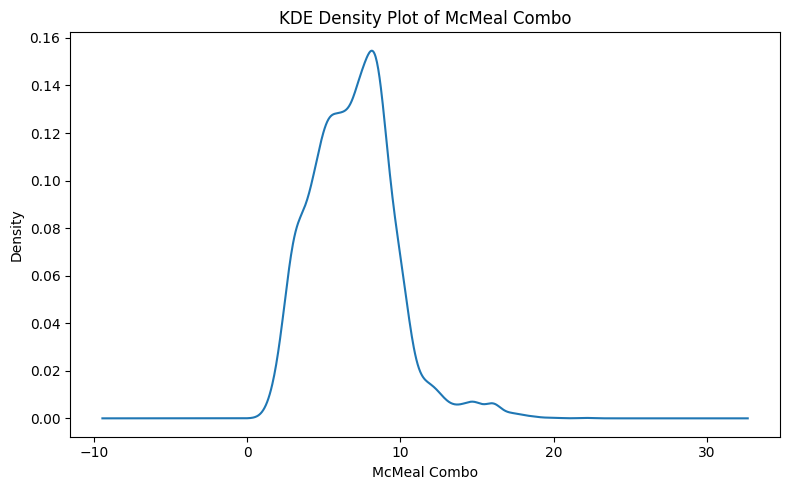

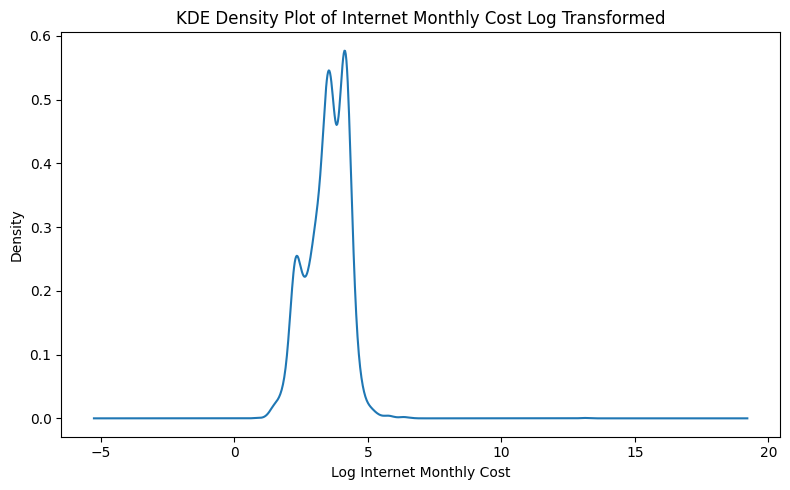

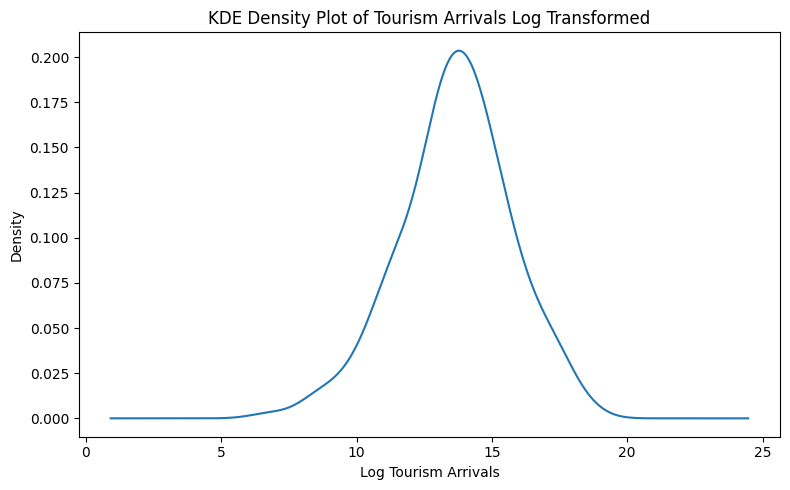

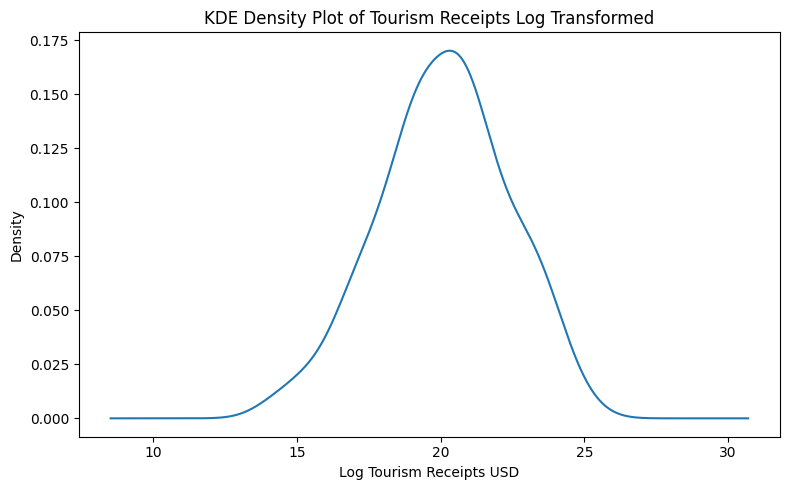

In [ ]:
# ----------------------------
# 6.5 KDE Density Plot
# Cost of Living first, then Tourism
# ----------------------------

# Cost of Living KDE: McMeal Combo
plt.figure(figsize=(8, 5))
cost_named["McMeal_Combo"].dropna().plot(kind="kde")
plt.title("KDE Density Plot of McMeal Combo")
plt.xlabel("McMeal Combo")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


# Cost of Living KDE: Internet Monthly Cost
# Use log transformation because Internet Monthly has extreme outliers
internet_log = np.log1p(cost_named["Internet_Monthly"].dropna())

plt.figure(figsize=(8, 5))
internet_log.plot(kind="kde")
plt.title("KDE Density Plot of Internet Monthly Cost Log Transformed")
plt.xlabel("Log Internet Monthly Cost")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


# Tourism KDE: Tourism Arrivals
arrivals_log = np.log1p(worldbank["Tourism_Arrivals"].dropna())

plt.figure(figsize=(8, 5))
arrivals_log.plot(kind="kde")
plt.title("KDE Density Plot of Tourism Arrivals Log Transformed")
plt.xlabel("Log Tourism Arrivals")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


# Tourism KDE: Tourism Receipts
receipts_log = np.log1p(worldbank["Tourism_Receipts_USD"].dropna())

plt.figure(figsize=(8, 5))
receipts_log.plot(kind="kde")
plt.title("KDE Density Plot of Tourism Receipts Log Transformed")
plt.xlabel("Log Tourism Receipts USD")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

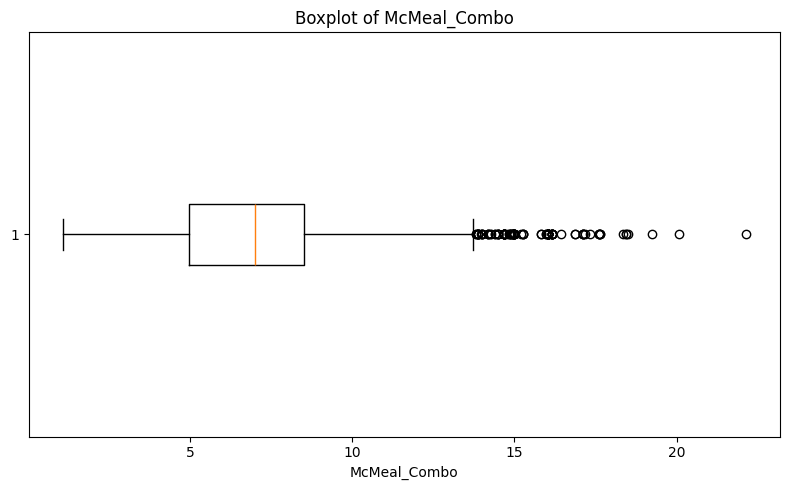

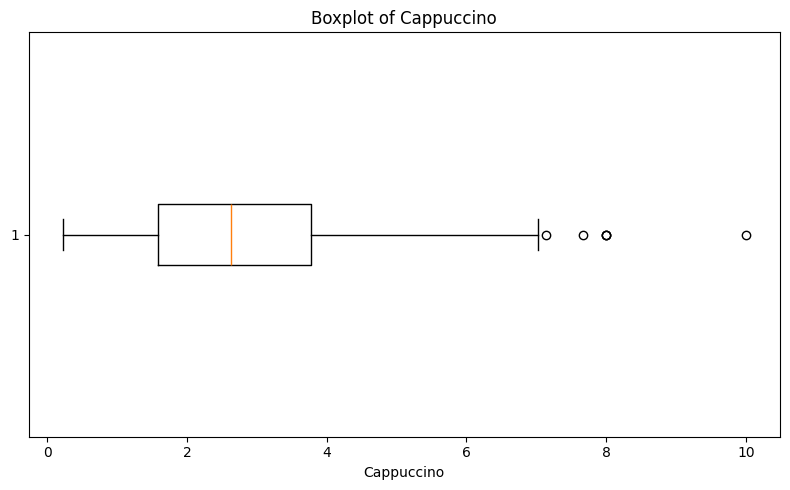

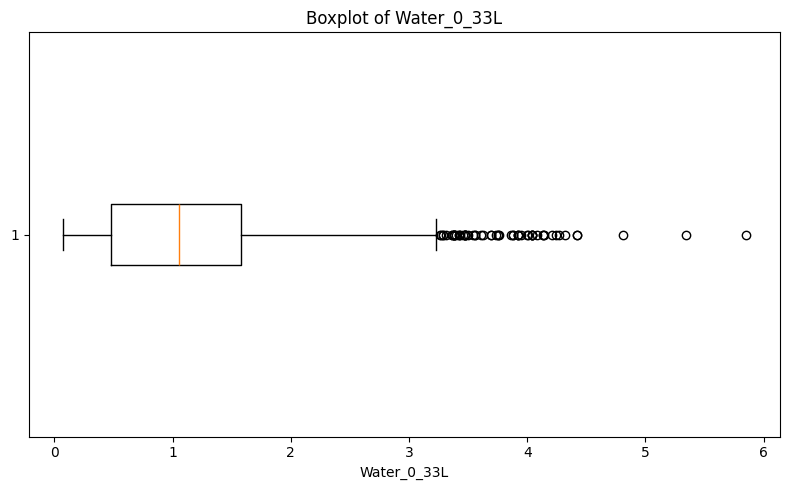

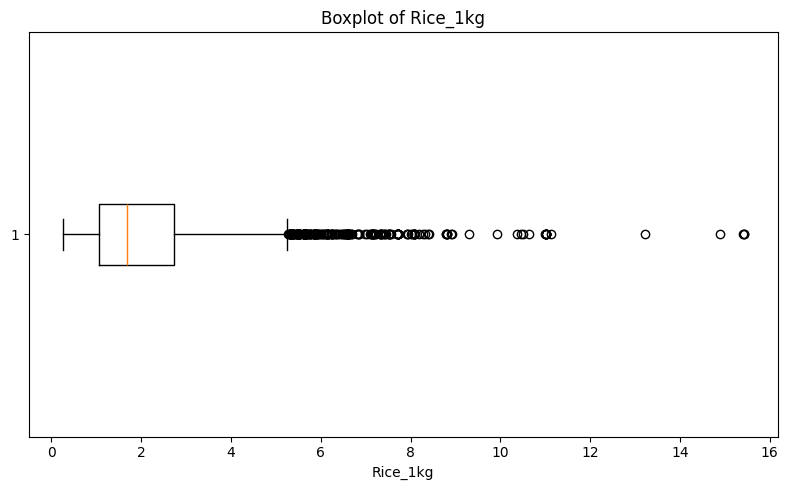

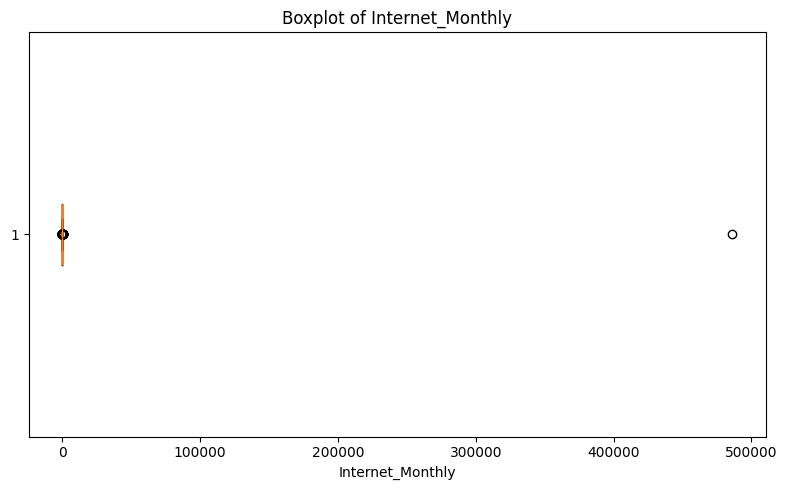

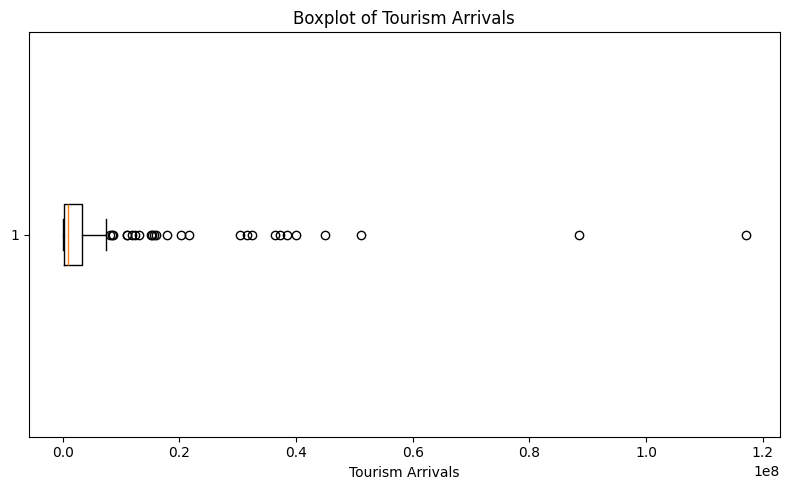

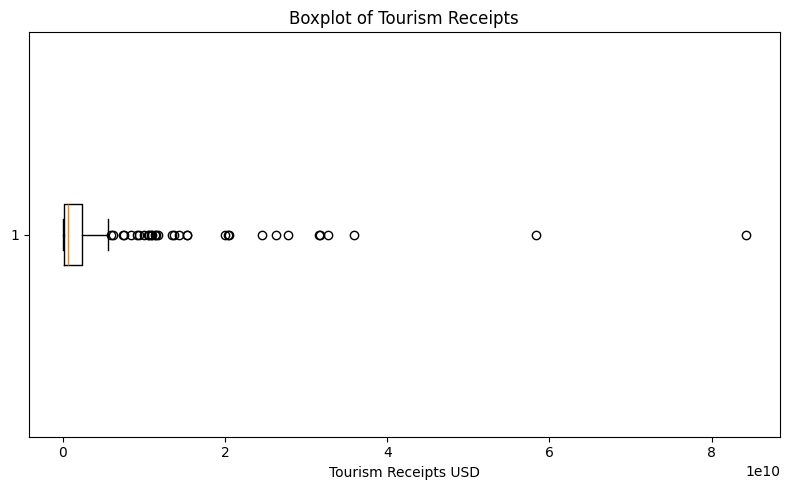

In [ ]:
# ----------------------------
# 6.7 Box Plot
# Cost of Living first, then Tourism
# ----------------------------

# Cost of Living selected indicators
selected_cost_cols = [
    "McMeal_Combo",
    "Cappuccino",
    "Water_0_33L",
    "Rice_1kg",
    "Internet_Monthly"
]

# Cost of Living boxplots
for col in selected_cost_cols:
    plt.figure(figsize=(8, 5))
    plt.boxplot(cost_named[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


# Tourism boxplot: Tourism Arrivals
plt.figure(figsize=(8, 5))
plt.boxplot(worldbank["Tourism_Arrivals"].dropna(), vert=False)
plt.title("Boxplot of Tourism Arrivals")
plt.xlabel("Tourism Arrivals")
plt.tight_layout()
plt.show()


# Tourism boxplot: Tourism Receipts
plt.figure(figsize=(8, 5))
plt.boxplot(worldbank["Tourism_Receipts_USD"].dropna(), vert=False)
plt.title("Boxplot of Tourism Receipts")
plt.xlabel("Tourism Receipts USD")
plt.tight_layout()
plt.show()

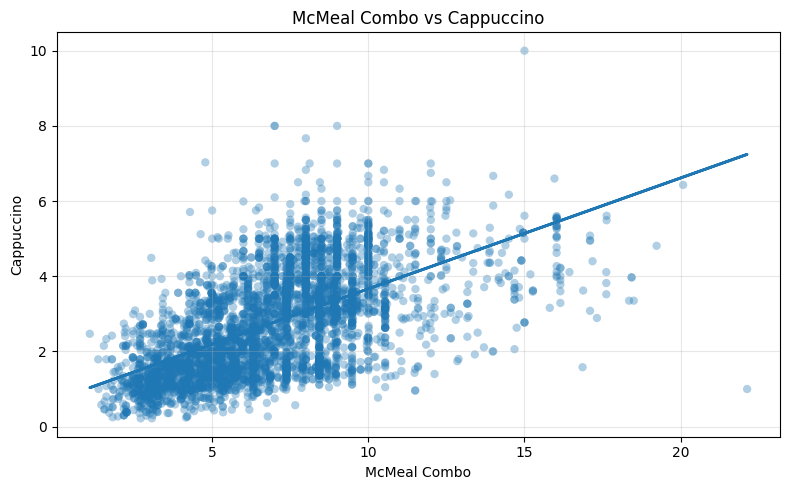

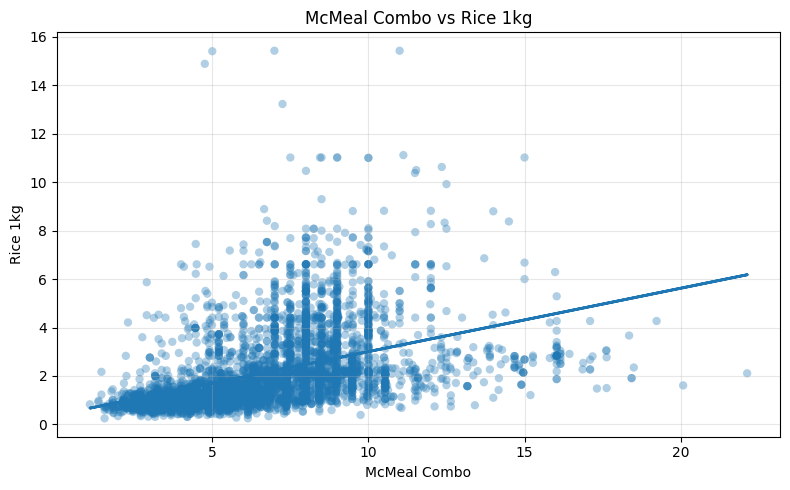

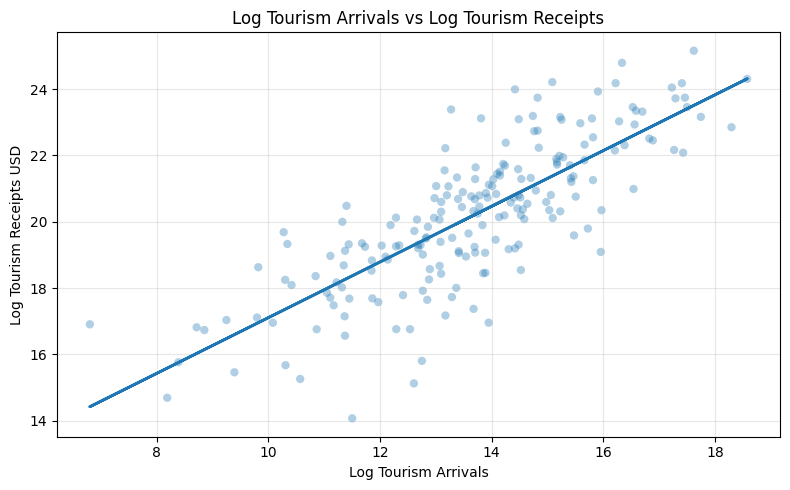

In [ ]:
# ----------------------------
# 6.8 Cleaner Scatter Plots
# Cost of Living first, then Tourism
# ----------------------------

import numpy as np
import matplotlib.pyplot as plt

# Helper function for clean scatter plots with trend line
def clean_scatter_plot(df, x_col, y_col, title, x_label, y_label):
    plot_data = df[[x_col, y_col]].dropna()

    x = plot_data[x_col]
    y = plot_data[y_col]

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, alpha=0.35, edgecolors="none")

    # Add trend line
    if len(plot_data) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        trend_line = slope * x + intercept
        plt.plot(x, trend_line, linewidth=2)

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Cost of Living Scatter Plot 1:
# McMeal Combo vs Cappuccino
# ------------------------------------------------------------

clean_scatter_plot(
    df=cost_named,
    x_col="McMeal_Combo",
    y_col="Cappuccino",
    title="McMeal Combo vs Cappuccino",
    x_label="McMeal Combo",
    y_label="Cappuccino"
)


# ------------------------------------------------------------
# Cost of Living Scatter Plot 2:
# McMeal Combo vs Rice 1kg
# ------------------------------------------------------------

clean_scatter_plot(
    df=cost_named,
    x_col="McMeal_Combo",
    y_col="Rice_1kg",
    title="McMeal Combo vs Rice 1kg",
    x_label="McMeal Combo",
    y_label="Rice 1kg"
)


# ------------------------------------------------------------
# Tourism Scatter Plot:
# Log Tourism Arrivals vs Log Tourism Receipts
# ------------------------------------------------------------

tourism_scatter = worldbank[["Tourism_Arrivals", "Tourism_Receipts_USD"]].dropna().copy()

# Log transform because tourism fields are highly skewed
tourism_scatter["Log_Tourism_Arrivals"] = np.log1p(tourism_scatter["Tourism_Arrivals"])
tourism_scatter["Log_Tourism_Receipts_USD"] = np.log1p(tourism_scatter["Tourism_Receipts_USD"])

clean_scatter_plot(
    df=tourism_scatter,
    x_col="Log_Tourism_Arrivals",
    y_col="Log_Tourism_Receipts_USD",
    title="Log Tourism Arrivals vs Log Tourism Receipts",
    x_label="Log Tourism Arrivals",
    y_label="Log Tourism Receipts USD"
)

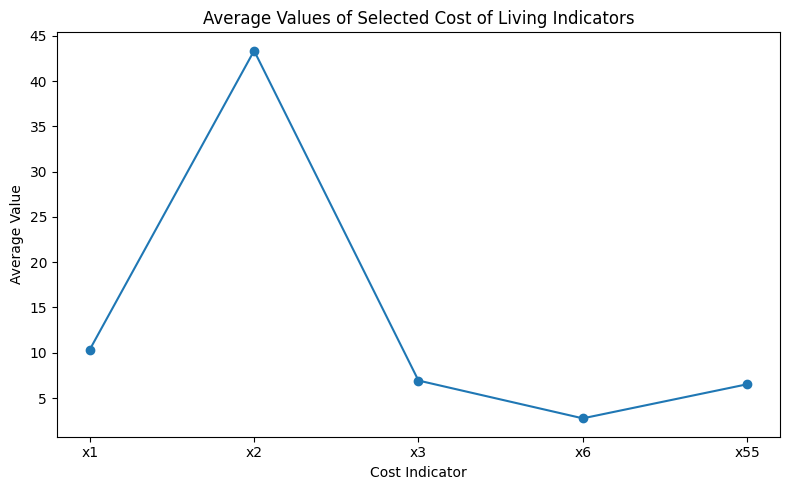

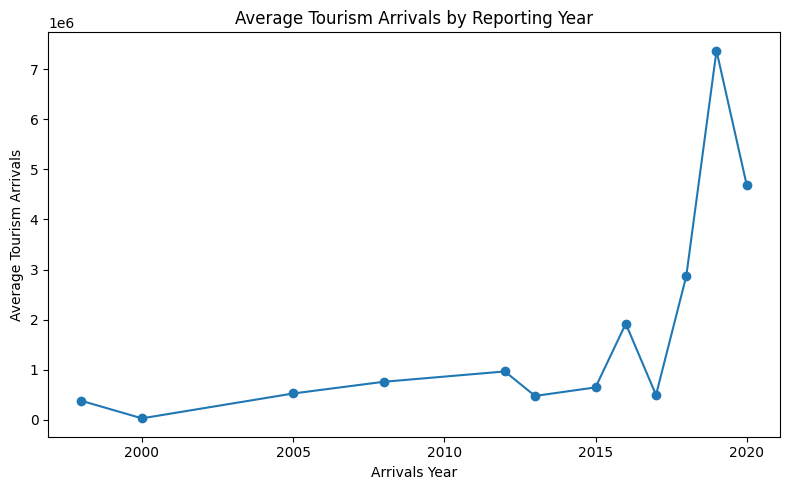

In [ ]:
# ----------------------------
# 6.1 Line Plot
# Cost of Living first, and  Tourism
# ----------------------------

# Cost of Living line plot:
# Average values of selected numeric cost indicators
selected_cost_cols = ["x1", "x2", "x3", "x6", "x55"]

cost_means = cost[selected_cost_cols].mean()

plt.figure(figsize=(8, 5))
plt.plot(cost_means.index, cost_means.values, marker="o")
plt.title("Average Values of Selected Cost of Living Indicators")
plt.xlabel("Cost Indicator")
plt.ylabel("Average Value")
plt.tight_layout()
plt.show()


# World Bank Tourism line plot:
# Average tourism arrivals by most recent reporting year
arrivals_by_year = (
    worldbank.groupby("Arrivals_Year")["Tourism_Arrivals"]
    .mean()
    .dropna()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.plot(arrivals_by_year.index, arrivals_by_year.values, marker="o")
plt.title("Average Tourism Arrivals by Reporting Year")
plt.xlabel("Arrivals Year")
plt.ylabel("Average Tourism Arrivals")
plt.tight_layout()
plt.show()

# Assignment 3 - Cost of Living

In [ ]:
import pandas as pd
import numpy as np

# Imports
import pandas as pd
import numpy as np
from scipy.stats import skew

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Load the data from my Google Drive
# Google Drive import removed; using organized Input/Output folders
# drive.mount removed; using organized Input/Output folders

path = INPUT_DIR / "kaggle_cost_of_living_clean.csv"

df_raw = pd.read_csv(path)
print(df_raw.columns.tolist())

print(f"Loaded dataset: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['city', 'country', 'destination_key', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'x50', 'x51', 'x52', 'x53', 'x54', 'x55', 'data_quality']
Loaded dataset: 4956 rows, 59 columns


,city,country,destination_key,x1,x2,x3,x4,x5,x6,x7,...,x47,x48,x49,x50,x51,x52,x53,x54,x55,data_quality
0,Gardez,Afghanistan,gardez_afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,Herat,Afghanistan,herat_afghanistan,1.69,6.21,2.82,2.26,NaN,0.56,0.40,...,19.77,62.15,39.55,112.99,79.10,480.78,248.42,152.54,10.30,0
2,Jalalabad,Afghanistan,jalalabad_afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,90.40,NaN,NaN,NaN,NaN,NaN,NaN,9.40,0
3,Kabul,Afghanistan,kabul_afghanistan,1.69,5.65,3.11,NaN,NaN,0.93,0.23,...,36.16,108.92,64.97,228.81,146.89,694.92,355.93,195.86,13.88,1
4,Mazar-e Sharif,Afghanistan,mazar-e_sharif_afghanistan,1.69,7.81,2.99,NaN,NaN,0.45,0.34,...,NaN,67.80,33.90,112.99,56.50,282.49,112.99,225.99,NaN,0


In [ ]:
# ==============================
# DATA CLEANING
# ==============================

# Missing values
missing_values = df_raw.isnull().sum()
print("Total Missing Values:", missing_values.sum())

# Show top columns with missing values
missing_values[missing_values > 0].sort_values(ascending=False).head(10)

Total Missing Values: 45858


,0
x40,2400
x53,2303
x52,2227
x29,2166
x43,1681
x51,1512
x28,1506
x50,1480
x54,1432
x49,1431


In [ ]:
# Check duplicates

print("Full row duplicates:", df_raw.duplicated().sum())

if {'city','country'}.issubset(df_raw.columns):
    print("City-Country duplicates:",
          df_raw.duplicated(subset=['city','country']).sum())

Full row duplicates: 0
City-Country duplicates: 0


In [ ]:
# Create working copy

cost = df_raw.copy()

# Remove rows where all cost columns are missing
numeric_cols = cost.select_dtypes(include=['number']).columns

cost = cost.dropna(subset=numeric_cols, how='all')

# Fill missing numeric values using median
cost[numeric_cols] = cost[numeric_cols].fillna(
    cost[numeric_cols].median()
)

print("Remaining missing values:", cost.isnull().sum().sum())
print("Shape after cleaning:", cost.shape)

Remaining missing values: 0
Shape after cleaning: (4956, 59)


In [ ]:
summary = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Missing Values", "Full Duplicates"],
    "Before Cleaning": [4956, 59, 45858, 0],
    "After Cleaning": [cost.shape[0], cost.shape[1], cost.isnull().sum().sum(), cost.duplicated().sum()]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Rows,4956,4956
1,Columns,59,59
2,Missing Values,45858,0
3,Full Duplicates,0,0


## Data Cleaning Results

The Cost of Living dataset was evaluated for missing values and duplicate records before analysis.

The dataset originally contained **45,858 missing values** across several cost-related variables. A duplicate check found **0 full-row duplicates** and **0 city-country duplicates**, indicating that each location record was unique.

To address the missing data, median imputation was applied to all numerical columns. Median imputation was selected because it is less sensitive to extreme values than mean imputation and helps preserve the overall distribution of the data.

After the cleaning process:
- Remaining missing values: **0**
- Full-row duplicates: **0**
- City-country duplicates: **0**
- Dataset shape: **4,956 rows × 59 columns**

These results indicate that the dataset is complete and ready for the next stage of preprocessing.

In [ ]:
# ==============================
# DATA TRANSFORMATION
# ==============================

from sklearn.preprocessing import MinMaxScaler

# Select numeric columns
numeric_cols = cost.select_dtypes(include=['number']).columns

# Create copy
cost_norm = cost.copy()

# Apply Min-Max Normalization
scaler = MinMaxScaler()

cost_norm[numeric_cols] = scaler.fit_transform(
    cost_norm[numeric_cols]
)

print("Normalized dataset shape:", cost_norm.shape)

print("Number of numerical features normalized:", len(numeric_cols))
print("Minimum normalized value:", cost_norm[numeric_cols].min().min())
print("Maximum normalized value:", cost_norm[numeric_cols].max().max())
cost_norm.head()

Normalized dataset shape: (4956, 59)
Number of numerical features normalized: 56
Minimum normalized value: 0.0
Maximum normalized value: 1.0000000000000002


,city,country,destination_key,x1,x2,x3,x4,x5,x6,x7,...,x47,x48,x49,x50,x51,x52,x53,x54,x55,data_quality
0,Gardez,Afghanistan,gardez_afghanistan,0.16,0.17,0.28,0.13,0.20,0.25,0.17,...,0.14,0.04,0.04,0.03,0.04,0.01,0.02,0.10,0.07,0.00
1,Herat,Afghanistan,herat_afghanistan,0.02,0.01,0.08,0.10,0.20,0.03,0.04,...,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.16,0.00
2,Jalalabad,Afghanistan,jalalabad_afghanistan,0.16,0.17,0.28,0.13,0.20,0.25,0.17,...,0.14,0.01,0.04,0.03,0.04,0.01,0.02,0.10,0.14,0.00
3,Kabul,Afghanistan,kabul_afghanistan,0.02,0.01,0.10,0.13,0.20,0.07,0.02,...,0.05,0.01,0.01,0.01,0.01,0.00,0.00,0.01,0.22,1.00
4,Mazar-e Sharif,Afghanistan,mazar-e_sharif_afghanistan,0.02,0.02,0.09,0.13,0.20,0.02,0.03,...,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.07,0.00


## Data Transformation Results

Data transformation was performed using **Min-Max normalization** on all numerical features in the Cost of Living dataset. Min-Max normalization rescales numerical values to a range between 0 and 1.

The results show that:

- The normalized dataset contains **4,956 rows and 59 columns**.
- A total of **56 numerical features** were normalized.
- The minimum normalized value is **0.0**.
- The maximum normalized value is approximately **1.0**.

The sample output above demonstrates that the original cost variables (x1–x55) have been successfully transformed into values between 0 and 1. This transformation ensures that variables measured on different scales do not disproportionately influence future data mining or machine learning models.

After normalization, the dataset is in a consistent, model-ready format and is suitable for further analysis.

In [ ]:
print("Number of numerical features:",
      len(numeric_cols))

print("\nFirst 10 numerical columns:")
print(list(numeric_cols[:10]))

Number of numerical features: 56

First 10 numerical columns:
['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10']


## Additional Transformation Results

The Cost of Living dataset contains **56 numerical features** that were identified for normalization. Examples of these numerical variables include x1 through x10, which represent different cost-of-living indicators.

These features were selected because machine learning algorithms generally perform better when numerical variables are on a similar scale. By normalizing all numerical features, the dataset becomes more suitable for future analysis and predictive modeling.

In [ ]:
countries = cost_norm['country'].nunique()

print(f"The dataset contains {countries} unique countries.")
print("Country will be used as the integration key with the World Bank Tourism dataset.")

The dataset contains 215 unique countries.
Country will be used as the integration key with the World Bank Tourism dataset.


## Data Integration Results

The Cost of Living dataset contains data for **215 unique countries**. This provides a strong basis for integration with the World Bank Tourism dataset because both datasets contain country-level information.

The common field available for integration is the **country** column. By standardizing country names and formats, the datasets can be merged to create a more comprehensive dataset containing both affordability and tourism-related information.

Data integration allows multiple data sources to be combined into a single dataset, providing a more complete view of potential travel destinations.

In [ ]:
# Keep only affordability-related features

cost_reduced = cost_norm.copy()

print("Reduced dataset shape:",
      cost_reduced.shape)

Reduced dataset shape: (4956, 59)


In [ ]:
important_cols = [
    'city',
    'country',
    'destination_key',
    'x1','x2','x3','x4','x5',
    'x8','x9','x10',
    'x18','x19','x20',
    'x52','x53'
]

cost_reduced = cost_norm[important_cols]

print("Original shape:", cost_norm.shape)
print("Reduced shape:", cost_reduced.shape)

Original shape: (4956, 59)
Reduced shape: (4956, 16)


## Data Reduction Results

Data reduction was performed to simplify the dataset while retaining the variables most relevant to identifying budget-friendly travel destinations.

The original normalized dataset contained **4,956 rows and 59 columns**. After reviewing the available attributes, the dataset was reduced to **4,956 rows and 16 columns** by selecting key affordability-related features, including restaurant prices, transportation costs, rent, housing prices, and location identifiers.

Reducing the number of variables decreases dataset complexity, improves processing efficiency, and helps focus future analysis on the factors most relevant to travel affordability. The reduced dataset preserves the most important information while removing less essential attributes.

In [ ]:
output_filename = OUTPUT_DIR / "kaggle_cost_of_living_prepared.csv"

cost_reduced.to_csv(output_filename, index=False)

print(f"Saved: {output_filename}")
print(f"Final shape: {cost_reduced.shape[0]} rows x {cost_reduced.shape[1]} columns")

Saved: kaggle_cost_of_living_prepared.csv
Final shape: 4956 rows x 16 columns


In [ ]:
# google.colab.files import removed; outputs are saved to OUTPUT_DIR
files.download(str(output_filename))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Export Cleaned Dataset

The cleaned, transformed, integration-ready Cost of Living dataset was exported as a CSV file for use in the dataset integration phase.

**Output File:** `kaggle_cost_of_living_reduced.csv`

**Final Dataset Size:** 4,956 rows × 16 columns

### Next Step:

This dataset can be integrated with the World Bank Tourism dataset using the **country** field as the common key. The resulting merged dataset will support the project's goal of identifying budget-friendly travel destinations by combining affordability and tourism indicators.

## Conclusion

The Cost of Living dataset was successfully cleaned, normalized, assessed for integration, and reduced from 59 to 16 features. The final dataset contains 4,956 rows and is ready for integration with the World Bank Tourism dataset.

# Assignment 3 - World Bank Tourism

In [ ]:
# Imports
import pandas as pd
import numpy as np
from scipy.stats import skew

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Load the data from my Google Drive
# Google Drive import removed; using organized Input/Output folders
# drive.mount removed; using organized Input/Output folders

path = INPUT_DIR / "worldbank_tourism_clean.csv"

df_raw = pd.read_csv(path)

print(f"Loaded dataset: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

Mounted at /content/drive
Loaded dataset: 208 rows, 6 columns


,Country,Country_Code,Arrivals_Year,Tourism_Arrivals,Receipts_Year,Tourism_Receipts_USD
0,Afghanistan,AFG,NaN,NaN,"2,020.00","75,000,000.00"
1,Albania,ALB,"2,020.00","2,658,000.00","2,020.00","1,243,000,000.00"
2,Algeria,DZA,"2,020.00","591,000.00","2,020.00","50,000,000.00"
3,American Samoa,ASM,"2,020.00",900.00,"2,017.00","22,000,000.00"
4,Andorra,AND,"2,020.00","5,207,000.00","2,019.00","1,910,000,000.00"


---
## 1. Data Cleaning

This section detects and resolves missing values, duplicates, and data quality
issues identified in our previous Data Understanding and Data Exploration reports.

### 1.1 Initial Data Quality Audit

In [ ]:
# Initial Data Quality Auditing

print("=" * 60)
print("INITIAL DATA QUALITY AUDIT")
print("=" * 60)

print(f"\nShape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")

print("\nColumn data types:")
print(df_raw.dtypes)

print("\nMissing values per column:")
print(df_raw.isnull().sum())

print(f"\nDuplicate Country_Code values: {df_raw['Country_Code'].duplicated().sum()}")
print(f"Duplicate Country name values: {df_raw['Country'].duplicated().sum()}")

print(f"\nAll Country_Code values are 3 characters (ISO3 format): "
      f"{(df_raw['Country_Code'].str.len() == 3).all()}")


INITIAL DATA QUALITY AUDIT

Shape: 208 rows x 6 columns

Column data types:
Country                  object
Country_Code             object
Arrivals_Year           float64
Tourism_Arrivals        float64
Receipts_Year           float64
Tourism_Receipts_USD    float64
dtype: object

Missing values per column:
Country                 0
Country_Code            0
Arrivals_Year           5
Tourism_Arrivals        5
Receipts_Year           5
Tourism_Receipts_USD    5
dtype: int64

Duplicate Country_Code values: 0
Duplicate Country name values: 0

All Country_Code values are 3 characters (ISO3 format): True


**Findings:**
- 208 country-level records, 6 columns one row per country, as confirmed in our Data Understanding Report.
- No duplicate countries or country codes each country appears exactly once.
- All `Country_Code` values are valid 3-letter ISO3 codes, which is the standard join key used across World Bank, UN, and most open datasets.
- 10 rows (4.8% of records) have a missing value in either `Tourism_Arrivals` or `Tourism_Receipts_USD`.

### 1.2 Identifying and Resolving Missing Values

In [ ]:
# Identifying and Resolve Missing Values

missing_rows = df_raw[df_raw.isnull().any(axis=1)]
print(f"Rows with at least one missing value: {len(missing_rows)}\n")
print(missing_rows[['Country', 'Country_Code', 'Tourism_Arrivals', 'Tourism_Receipts_USD']]
      .to_string(index=False))

Rows with at least one missing value: 10

          Country Country_Code  Tourism_Arrivals  Tourism_Receipts_USD
      Afghanistan          AFG               NaN         75,000,000.00
Equatorial Guinea          GNQ               NaN         14,000,000.00
             Guam          GUM        328,000.00                   NaN
          Liberia          LBR               NaN        123,000,000.00
    Liechtenstein          LIE         58,400.00                   NaN
           Monaco          MCO        159,000.00                   NaN
            Nauru          NRU               NaN          1,600,000.00
       San Marino          SMR      1,904,000.00                   NaN
      South Sudan          SSD               NaN         12,000,000.00
           Zambia          ZMB        502,000.00                   NaN


**Decision: Drop incomplete rows (complete-case approach).**

Of the 10 affected countries, 5 are missing only `Tourism_Arrivals` (Afghanistan,
Equatorial Guinea, Liberia, Nauru, South Sudan) and 5 are missing only
`Tourism_Receipts_USD` (Guam, Liechtenstein, Monaco, San Marino, Zambia). No country
is missing both fields.

The team chose to **drop these 10 rows** rather than impute, for two reasons:

1. **No reliable basis for imputation exists in this dataset.** There is no
   region/income-group column to ground a defensible substitute value, and
   estimating tourism arrivals or receipts for a country from unrelated countries'
   values would introduce fabricated numbers into a "ground truth" indicator field.
2. **Consistency for merging.** Since the final analysis emphasizes destinations with
   strong data coverage across all six sources (per our Data Exploration Report's
   recommendation to favor a smaller, well-covered destination list over forcing in
   incomplete records), a complete-case tourism table is preferable to one with
   estimated values mixed in.

This is a defensible, standard data-cleaning choice given the small proportion of
affected rows (4.8%) relative to the full dataset.

In [ ]:
# Drop rows missing core tourism indicators

rows_before = len(df_raw)
df_clean = df_raw.dropna(subset=['Tourism_Arrivals', 'Tourism_Receipts_USD']).copy()
rows_dropped = rows_before - len(df_clean)

print(f"Rows before cleaning: {rows_before}")
print(f"Rows dropped (missing arrivals or receipts): {rows_dropped}")
print(f"Rows after cleaning: {len(df_clean)}")

# Re-verify no missing values remain in the core indicator columns
assert df_clean['Tourism_Arrivals'].isnull().sum() == 0
assert df_clean['Tourism_Receipts_USD'].isnull().sum() == 0
print("\nConfirmed: no missing values remain in Tourism_Arrivals or Tourism_Receipts_USD.")


Rows before cleaning: 208
Rows dropped (missing arrivals or receipts): 10
Rows after cleaning: 198

Confirmed: no missing values remain in Tourism_Arrivals or Tourism_Receipts_USD.


### 1.3 Data Consistency Check - Reporting Year Coverage

The `Arrivals_Year` and `Receipts_Year` columns record which year each country's
figures come from. Because World Bank countries report on different schedules, not
every country's "most recent" figure is from the same year — some are several years
older. This is a **data consistency / data quality issue** (not a missing-value
issue) worth flagging explicitly, since stale figures could be a noisy/inconsistent
signal once merged with more current data (e.g., 2026 flight prices or weather data).

In [ ]:
# Reporting Year Consistency Check

print("Distribution of Arrivals_Year:")
print(df_clean['Arrivals_Year'].value_counts().sort_index(ascending=False))

print("\nDistribution of Receipts_Year:")
print(df_clean['Receipts_Year'].value_counts().sort_index(ascending=False))

# Flag records whose reporting year is more than ~2 years older than the most
# common reporting year (2020), since these are comparatively stale figures.
STALE_YEAR_THRESHOLD = 2018

df_clean['Arrivals_Year'] = df_clean['Arrivals_Year'].astype(int)
df_clean['Receipts_Year'] = df_clean['Receipts_Year'].astype(int)

df_clean['Arrivals_Data_Is_Stale'] = df_clean['Arrivals_Year'] < STALE_YEAR_THRESHOLD
df_clean['Receipts_Data_Is_Stale'] = df_clean['Receipts_Year'] < STALE_YEAR_THRESHOLD

n_stale_arrivals = df_clean['Arrivals_Data_Is_Stale'].sum()
n_stale_receipts = df_clean['Receipts_Data_Is_Stale'].sum()

print(f"\nCountries with arrivals data older than {STALE_YEAR_THRESHOLD}: {n_stale_arrivals}")
print(f"Countries with receipts data older than {STALE_YEAR_THRESHOLD}: {n_stale_receipts}")


Distribution of Arrivals_Year:
Arrivals_Year
2,020.00    128
2,019.00     46
2,018.00      7
2,017.00      5
2,016.00      3
2,015.00      2
2,013.00      2
2,012.00      1
2,008.00      1
2,005.00      1
2,000.00      1
1,998.00      1
Name: count, dtype: int64

Distribution of Receipts_Year:
Receipts_Year
2,020.00    128
2,019.00     12
2,018.00     22
2,017.00      3
2,016.00      7
2,015.00      2
2,013.00      2
2,011.00      4
2,010.00      2
2,008.00      2
2,007.00      2
2,004.00      2
2,003.00      1
2,002.00      2
1,999.00      2
1,998.00      3
1,997.00      1
1,995.00      1
Name: count, dtype: int64

Countries with arrivals data older than 2018: 17
Countries with receipts data older than 2018: 36


**Finding:** Most countries (≈85%) report 2018–2020 figures, but a meaningful
minority report older data receipts data goes as far back as 1995 for a handful of
countries. Rather than dropping these (which would lose real countries needed for
ranking), we **flag them with a boolean indicator column** so downstream modeling can
choose to exclude, down-weight, or simply be aware of these records. This preserves
information instead of silently discarding it.

### 1.4 Outlier Review

Our Data Exploration Report already identified that `Tourism_Arrivals` and
`Tourism_Receipts_USD` are highly right-skewed, with a small number of countries
showing very large values. We re-confirm this here and inspect whether the extreme
values are legitimate or signs of data error.

In [ ]:
# Outlier Review

def iqr_outlier_summary(series, label):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    outliers = series[series > upper_bound]
    print(f"{label}: {len(outliers)} values above the IQR upper bound ({upper_bound:,.0f})")
    return outliers

arrivals_outliers = iqr_outlier_summary(df_clean['Tourism_Arrivals'], 'Tourism_Arrivals')
receipts_outliers = iqr_outlier_summary(df_clean['Tourism_Receipts_USD'], 'Tourism_Receipts_USD')

print("\nTop 10 countries by tourism arrivals (highest outliers):")
print(df_clean.nlargest(10, 'Tourism_Arrivals')[['Country', 'Tourism_Arrivals']].to_string(index=False))


Tourism_Arrivals: 25 values above the IQR upper bound (8,189,350)
Tourism_Receipts_USD: 30 values above the IQR upper bound (6,246,312,500)

Top 10 countries by tourism arrivals (highest outliers):
       Country  Tourism_Arrivals
        France    117,109,000.00
        Poland     88,515,000.00
        Mexico     51,128,000.00
 United States     45,037,000.00
      Thailand     39,916,000.00
         Italy     38,419,000.00
Czech Republic     37,202,000.00
         Spain     36,410,000.00
        Canada     32,430,000.00
       Hungary     31,641,000.00


**Decision: Keep all outliers.** The highest-arrival countries (France, Poland,
Mexico, the United States, Thailand, etc.) are well-known major tourism destinations.
These extreme values reflect genuine real-world differences in tourism scale, not
data entry errors, so removing them would discard valid and important information.
This matches the same outlier philosophy our team applied to the Cost of Living and
Inside Airbnb datasets (real high-cost cities and luxury listings were kept, not
deleted, only down-weighted via median-based statistics or log transformation).

---
## 2. Data Transformation

This section renames columns to clear, descriptive names; engineers a couple of
analysis-ready features; and applies a log transformation to correct the strong
right-skew identified in our Data Exploration Report while preserving the original
raw values so the merge step (Section 3) still has true, untransformed indicators
available.

### 2.1 Descriptive Column Renaming

The raw World Bank export uses short, somewhat ambiguous column names. We rename
every column to a clear, self-explanatory name using a consistent
`snake_case` convention that matches the naming style used by the team across the
other five datasets (see `location_path`, `weather_score`, `median_airbnb_price_usd`,
etc. in the team's other reports). No column is left with a generic name.

In [ ]:
# Descriptive Column Renaming

column_rename_map = {
    'Country':                 'country_name',
    'Country_Code':             'country_code',          # ISO3 — primary merge key
    'Arrivals_Year':            'tourism_arrivals_year',
    'Tourism_Arrivals':         'tourism_arrivals_count',
    'Receipts_Year':            'tourism_receipts_year',
    'Tourism_Receipts_USD':     'tourism_receipts_usd',
    'Arrivals_Data_Is_Stale':   'tourism_arrivals_is_stale',
    'Receipts_Data_Is_Stale':   'tourism_receipts_is_stale',
}

df_clean = df_clean.rename(columns=column_rename_map)

print("Renamed columns:")
for old, new in column_rename_map.items():
    print(f"  {old:25s} -> {new}")

df_clean.head()

Renamed columns:
  Country                   -> country_name
  Country_Code              -> country_code
  Arrivals_Year             -> tourism_arrivals_year
  Tourism_Arrivals          -> tourism_arrivals_count
  Receipts_Year             -> tourism_receipts_year
  Tourism_Receipts_USD      -> tourism_receipts_usd
  Arrivals_Data_Is_Stale    -> tourism_arrivals_is_stale
  Receipts_Data_Is_Stale    -> tourism_receipts_is_stale


,country_name,country_code,tourism_arrivals_year,tourism_arrivals_count,tourism_receipts_year,tourism_receipts_usd,tourism_arrivals_is_stale,tourism_receipts_is_stale
1,Albania,ALB,2020,"2,658,000.00",2020,"1,243,000,000.00",False,False
2,Algeria,DZA,2020,"591,000.00",2020,"50,000,000.00",False,False
3,American Samoa,ASM,2020,900.00,2017,"22,000,000.00",False,True
4,Andorra,AND,2020,"5,207,000.00",2019,"1,910,000,000.00",False,False
5,Angola,AGO,2019,"218,000.00",2020,"19,000,000.00",False,False


### 2.2 Feature Engineering — Receipts per Arrival

We add one derived feature: **tourism receipts per arrival** (USD spent, on average,
per international tourist). This is a genuinely new signal not a duplicate of the
two source columns because it captures *spending intensity* rather than *volume*.
A country can have low arrivals but high per-tourist spending (luxury destinations)
or high arrivals but low per-tourist spending (budget mass-tourism destinations).
This is directly relevant to the team's Budget Value Index, since it helps
distinguish "high tourist volume" from "high tourist value."

In [ ]:
# Feature Engineering

df_clean['tourism_receipts_per_arrival_usd'] = (
    df_clean['tourism_receipts_usd'] / df_clean['tourism_arrivals_count']
)

print("tourism_receipts_per_arrival_usd summary:")
print(df_clean['tourism_receipts_per_arrival_usd'].describe())

print("\nTop 5 countries by receipts per arrival (highest average spend per tourist):")
print(df_clean.nlargest(5, 'tourism_receipts_per_arrival_usd')
      [['country_name', 'tourism_receipts_per_arrival_usd']].to_string(index=False))

print("\nBottom 5 countries by receipts per arrival (lowest average spend per tourist):")
print(df_clean.nsmallest(5, 'tourism_receipts_per_arrival_usd')
      [['country_name', 'tourism_receipts_per_arrival_usd']].to_string(index=False))


tourism_receipts_per_arrival_usd summary:
count      198.00
mean     1,653.89
std      3,139.48
min         12.37
25%        289.94
50%        780.80
75%      1,608.53
max     24,601.37
Name: tourism_receipts_per_arrival_usd, dtype: float64

Top 5 countries by receipts per arrival (highest average spend per tourist):
  country_name  tourism_receipts_per_arrival_usd
         Qatar                         24,601.37
American Samoa                         24,444.45
     Australia                         14,351.20
       Moldova                         12,206.90
   New Zealand                         11,005.02

Bottom 5 countries by receipts per arrival (lowest average spend per tourist):
   country_name  tourism_receipts_per_arrival_usd
        Burundi                             12.37
         Guinea                             13.03
        Lesotho                             20.23
       Eswatini                             21.14
Kyrgyz Republic                             22.92


### 2.3 Log Transformation for Skewed Numeric Fields

Our Data Exploration Report measured strong positive skew in both core numeric
fields (`Tourism_Arrivals` skew ≈ 5.32, `Tourism_Receipts_USD` skew ≈ 4.86 these
exact values are recomputed below on the cleaned dataset and may differ slightly
from the original due to the 10 dropped rows). Many data mining algorithms
(e.g., k-means clustering, linear/logistic regression, distance-based methods)
assume or perform better with roughly symmetric numeric inputs, so this needs
correcting before modeling.

We apply `log1p()` (`log(1 + x)`, which safely handles any value ≥ 0) and add the
result as **new columns**, keeping the original raw columns untouched. This way:
- The raw country-level values stay available and human-readable for the report and for merging.
- Whoever runs the modeling phase already has skew-corrected columns ready to use, without redoing this step.

In [ ]:
# Log Transformation

print("Skewness BEFORE log transformation:")
skew_arrivals_before = skew(df_clean['tourism_arrivals_count'])
skew_receipts_before = skew(df_clean['tourism_receipts_usd'])
print(f"  tourism_arrivals_count : {skew_arrivals_before:.3f}")
print(f"  tourism_receipts_usd   : {skew_receipts_before:.3f}")

df_clean['log_tourism_arrivals'] = np.log1p(df_clean['tourism_arrivals_count'])
df_clean['log_tourism_receipts_usd'] = np.log1p(df_clean['tourism_receipts_usd'])

print("\nSkewness AFTER log transformation:")
skew_arrivals_after = skew(df_clean['log_tourism_arrivals'])
skew_receipts_after = skew(df_clean['log_tourism_receipts_usd'])
print(f"  log_tourism_arrivals     : {skew_arrivals_after:.3f}")
print(f"  log_tourism_receipts_usd : {skew_receipts_after:.3f}")

print("\nInterpretation: Skewness near 0 indicates a roughly symmetric distribution.")
print(f"Log transformation reduced arrivals skew from {skew_arrivals_before:.2f} to {skew_arrivals_after:.2f},")
print(f"and receipts skew from {skew_receipts_before:.2f} to {skew_receipts_after:.2f} — both now close to symmetric.")


Skewness BEFORE log transformation:
  tourism_arrivals_count : 5.320
  tourism_receipts_usd   : 4.855

Skewness AFTER log transformation:
  log_tourism_arrivals     : -0.323
  log_tourism_receipts_usd : -0.178

Interpretation: Skewness near 0 indicates a roughly symmetric distribution.
Log transformation reduced arrivals skew from 5.32 to -0.32,
and receipts skew from 4.86 to -0.18 — both now close to symmetric.


**Note on normalization/scaling:** We deliberately do **not** apply min-max scaling
or z-score standardization in this notebook. Scaling should happen *after* the full
team merge across all six datasets, since scaling this dataset's columns in isolation
would produce different ranges than scaling them as part of the complete feature set.
This keeps the order of operations consistent with CRISP-DM and with our project
plan (Data Preparation → Modeling). The log-transformed columns above are the
exception: they correct a structural skew specific to this indicator, independent of
any other dataset's scale, so it's safe and useful to do that step now.

---
## 3. Data Integration Readiness

This dataset will be merged with the team's other five sources (Cost of Living,
Inside Airbnb, TripAdvisor Reviews, Flight Offers, Climate/Weather) into one
destination-level table for modeling. This section documents how this dataset is
positioned for that merge.

### 3.1 Merge Key

- **Primary merge key: `country_code`** (ISO3, e.g., `USA`, `FRA`, `THA`).
- ISO3 codes are the standardized identifier used by the World Bank and most major
  open datasets, which avoids the naming inconsistencies our team already
  encountered elsewhere (e.g., "New York" vs. "New York City, NY"; "Congo, Dem. Rep."
  vs. "Democratic Republic of the Congo").
- `country_name` is also kept as a human-readable fallback/display field, but should
  **not** be used as the join key due to spelling and formatting differences across
  sources.

### 3.2 Geographic Level Mismatch — Known Integration Challenge

This is a **country-level** dataset (1 row = 1 country), while several of the team's
other sources are **city-level** (Cost of Living, Inside Airbnb, Climate/Weather) or
**route/airport-level** (Flight Offers). This mismatch was already identified in our
Data Understanding and Data Exploration reports as the single largest integration
risk for the project.

**How this dataset fits into the resolution plan:**
- This table will be joined onto the team's master destination lookup table by
  mapping each city-level destination's *country* to its corresponding `country_code`.
- Every city in a given country will share the same tourism arrivals/receipts values,
  since this indicator is only available at the national level. This is expected and
  should be documented in the final merged dataset (e.g., multiple Italian cities will
  all carry Italy's national tourism figures).
- No further city-level disaggregation is possible from this source; this is a known
  and accepted limitation of using a national indicator alongside city-level data.

### 3.3 Pre-Merge Validation

In [ ]:
# Pre-Merge Validation

print("Final pre-merge dataset summary")
print("=" * 60)
print(f"Rows (countries): {len(df_clean)}")
print(f"Columns: {len(df_clean.columns)}")
print(f"\nColumn list:\n{list(df_clean.columns)}")

print(f"\nMerge key 'country_code' is unique: {df_clean['country_code'].is_unique}")
print(f"Merge key 'country_code' has no missing values: {df_clean['country_code'].notnull().all()}")
print(f"All country_code values are exactly 3 characters: "
      f"{(df_clean['country_code'].str.len() == 3).all()}")

print("\nNo remaining missing values in any column:")
print(df_clean.isnull().sum())

Final pre-merge dataset summary
Rows (countries): 198
Columns: 11

Column list:
['country_name', 'country_code', 'tourism_arrivals_year', 'tourism_arrivals_count', 'tourism_receipts_year', 'tourism_receipts_usd', 'tourism_arrivals_is_stale', 'tourism_receipts_is_stale', 'tourism_receipts_per_arrival_usd', 'log_tourism_arrivals', 'log_tourism_receipts_usd']

Merge key 'country_code' is unique: True
Merge key 'country_code' has no missing values: True
All country_code values are exactly 3 characters: True

No remaining missing values in any column:
country_name                        0
country_code                        0
tourism_arrivals_year               0
tourism_arrivals_count              0
tourism_receipts_year               0
tourism_receipts_usd                0
tourism_arrivals_is_stale           0
tourism_receipts_is_stale           0
tourism_receipts_per_arrival_usd    0
log_tourism_arrivals                0
log_tourism_receipts_usd            0
dtype: int64


### 3.4 Final Cleaned & Transformed Dataset Preview

In [ ]:
# Final Preview
df_clean.head(10)

,country_name,country_code,tourism_arrivals_year,tourism_arrivals_count,tourism_receipts_year,tourism_receipts_usd,tourism_arrivals_is_stale,tourism_receipts_is_stale,tourism_receipts_per_arrival_usd,log_tourism_arrivals,log_tourism_receipts_usd
1,Albania,ALB,2020,"2,658,000.00",2020,"1,243,000,000.00",False,False,467.64,14.79,20.94
2,Algeria,DZA,2020,"591,000.00",2020,"50,000,000.00",False,False,84.60,13.29,17.73
3,American Samoa,ASM,2020,900.00,2017,"22,000,000.00",False,True,"24,444.45",6.80,16.91
4,Andorra,AND,2020,"5,207,000.00",2019,"1,910,000,000.00",False,False,366.81,15.47,21.37
5,Angola,AGO,2019,"218,000.00",2020,"19,000,000.00",False,False,87.16,12.29,16.76
6,Antigua and Barbuda,ATG,2020,"384,500.00",2020,"416,000,000.00",False,False,"1,081.92",12.86,19.85
7,Argentina,ARG,2019,"7,399,000.00",2020,"1,702,000,000.00",False,False,230.03,15.82,21.26
8,Armenia,ARM,2020,"375,000.00",2020,"303,000,000.00",False,False,808.00,12.83,19.53
9,Aruba,ABW,2019,"1,951,000.00",2020,"1,077,000,000.00",False,False,552.02,14.48,20.80
10,Australia,AUS,2020,"1,828,000.00",2020,"26,234,000,000.00",False,False,"14,351.20",14.42,23.99


In [ ]:
# Column-by-column description for the report

final_column_descriptions = {
    'country_name':                      'Full country name (display/reference only — do not use for merging)',
    'country_code':                       'ISO3 country code — PRIMARY MERGE KEY for joining with other datasets',
    'tourism_arrivals_year':              'Most recent year available for tourism arrivals figure',
    'tourism_arrivals_count':             'Number of international tourist arrivals (raw, original scale)',
    'tourism_receipts_year':              'Most recent year available for tourism receipts figure',
    'tourism_receipts_usd':               'International tourism receipts in current U.S. dollars (raw, original scale)',
    'tourism_arrivals_is_stale':          'True if arrivals figure is older than 2018 (data quality flag)',
    'tourism_receipts_is_stale':          'True if receipts figure is older than 2018 (data quality flag)',
    'tourism_receipts_per_arrival_usd':   'Engineered feature: average USD tourism receipt per tourist arrival',
    'log_tourism_arrivals':               'Log-transformed (log1p) tourism arrivals — skew-corrected, ready for modeling',
    'log_tourism_receipts_usd':           'Log-transformed (log1p) tourism receipts — skew-corrected, ready for modeling',
}

for col, desc in final_column_descriptions.items():
    print(f"{col:38s} {desc}")

country_name                           Full country name (display/reference only — do not use for merging)
country_code                           ISO3 country code — PRIMARY MERGE KEY for joining with other datasets
tourism_arrivals_year                  Most recent year available for tourism arrivals figure
tourism_arrivals_count                 Number of international tourist arrivals (raw, original scale)
tourism_receipts_year                  Most recent year available for tourism receipts figure
tourism_receipts_usd                   International tourism receipts in current U.S. dollars (raw, original scale)
tourism_arrivals_is_stale              True if arrivals figure is older than 2018 (data quality flag)
tourism_receipts_is_stale              True if receipts figure is older than 2018 (data quality flag)
tourism_receipts_per_arrival_usd       Engineered feature: average USD tourism receipt per tourist arrival
log_tourism_arrivals                   Log-transformed (log1p) tour

---
## 4. Export Cleaned Dataset

Save the cleaned, transformed, integration-ready dataset as a new CSV file for the
team to use in the merge step.

In [ ]:
# Export File

output_filename = OUTPUT_DIR / "worldbank_tourism_prepared.csv"
df_clean.to_csv(output_filename, index=False)

print(f"Saved: {output_filename}")
print(f"Final shape: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")

# This downloads the file to your computer
# google.colab.files import removed; outputs are saved to OUTPUT_DIR
files.download(output_filename)

Saved: worldbank_tourism_prepared.csv
Final shape: 198 rows x 11 columns


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Next step for the team:** use `country_code` to join this table onto the master
destination lookup (mapping each city-level destination to its country), per the
integration plan in Section 3.2.